# Marathon Start – Hughes Model (v4)

Extension of `Hughes_model_28_05.ipynb` with a **realistic marathon start**:

| Feature | Base notebook | This notebook |
|---------|--------------|---------------|
| Domain | Square / Huang 100×50 m | Corridor 200 m × 20 m |
| Inflow | Constant or Huang ramp | **4 waves with 20 s gaps, realistic crowd sizes** |
| Speed law | Fixed `u_max` | **Wave-specific `u_max`** |
| Obstacles | Rectangle (Huang) | **Rectangle + Triangle (apex upstream)** |
| Output | Static snapshots | **Animated GIF + timeline bar** |

## Wave design (based on real marathon data)

| Wave | Window | Group | N runners | Flux [ped/m/s] | u_max [m/s] |
|------|--------|-------|-----------|----------------|-------------|
| 1 | 0–20 s | Elite | ~40 | 0.10 | 1.40 |
| GAP | 20–40 s | — | — | 0 | — |
| 2 | 40–110 s | Fast sub-3h | ~490 | 0.35 | 1.10 |
| GAP | 110–130 s | — | — | 0 | — |
| 3 | 130–230 s | Intermediate | ~960 | 0.48 | 0.80 |
| GAP | 230–250 s | — | — | 0 | — |
| 4 | 250–370 s | Slow/walkers | ~1320 | 0.55 | 0.60 |
| DRAIN | > 370 s | — | — | 0 | 1.40 |

Fluxes are calibrated so the corridor **never jams** (all below bypass capacity of the obstacle).


## Imports

In [1]:
import numpy as np
import matplotlib
matplotlib.use('Agg')       # use non-interactive backend for GIF saving
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Polygon as MplPolygon
import time, warnings
warnings.filterwarnings("ignore")


---
## Part 1 – Base Functions (copied verbatim from `Hughes_model_28_05.ipynb`)


### 1.1 `define_mesh` — base Cell 1

In [2]:
import numpy as np

def define_mesh(Nx, Ny=None, Lx=1.0, Ly=None):
    """
    Build a (possibly rectangular) uniform mesh.

    If Ny is None, a square Nx x Nx mesh on [0,Lx]x[0,Lx] is built (legacy).
    For the Huang validation case pass Nx=100, Ny=50, Lx=100.0, Ly=50.0.
    """
    if Ny is None:
        Ny = Nx
    if Ly is None:
        Ly = Lx

    hx = Lx / Nx
    hy = Ly / Ny

    x = (np.arange(Nx) + 0.5) * hx
    y = (np.arange(Ny) + 0.5) * hy
    X, Y = np.meshgrid(x, y, indexing='ij')

    # For square grids (hx == hy) a single h is returned for convenience.
    h = hx  # callers that need both can use hx / hy directly

    print(f"Mesh generated: Nx={Nx}, Ny={Ny}, hx={hx:.4f}, hy={hy:.4f}")
    return x, y, X, Y, h


### 1.2 `build_all_boundary_masks` — base Cell 4

In [3]:
def build_all_boundary_masks(Nx, Ny, gamma_i, gamma_d, gamma_h):
    inflow_mask = np.zeros((Nx, Ny), dtype=bool)
    dest_mask   = np.zeros((Nx, Ny), dtype=bool)
    wall_mask   = np.zeros((Nx, Ny), dtype=bool)

    for i, j in gamma_i:
        inflow_mask[i, j] = True
    for i, j in gamma_d:
        dest_mask[i, j] = True
    for i, j in gamma_h:
        wall_mask[i, j] = True

    return inflow_mask, dest_mask, wall_mask


### 1.3 `compute_speed`, `compute_cost` — base Cell 10

`compute_speed` accepts `u_max` as a keyword — this is the hook used to give
each wave a different free-flow speed.


In [4]:
def compute_speed(rho, rho_max=1.0, u_max=1.0, eps=1e-8):
    """
    Isotropic speed law u(rho).
    Simple dimensionless linear choice:
        u(rho) = u_max * (1 - rho/rho_max)
    clipped below by eps to avoid division issues later.
    """
    u = u_max * (1.0 - rho / rho_max)
    return np.maximum(u, eps)


def compute_flux_magnitude(rho, rho_max=1.0, u_max=1.0):
    """
    Section 4.3: compute ||f|| from formula (25):
        ||f|| = rho * u(rho)
    """
    u = compute_speed(rho, rho_max=rho_max, u_max=u_max)
    f_norm = rho * u
    return f_norm

def compute_cost(rho, alpha=0.5, mode="huang"):
    """
    Computes the local cost c(rho).
    """
    u = compute_speed(rho)
    u_safe = np.maximum(u, 0.05)

    mode = mode.lower()

    if mode == "simple":
        return 1.0 / u_safe

    elif mode == "hughes":
        g_inv = np.exp(alpha * rho**2)
        return g_inv / u_safe

    elif mode == "huang":                              #more stable than hughes
        g = 0.002 * rho**2
        return 1.0 / u_safe + g

    else:
        raise ValueError("Unknown cost mode.")

# Note: In the paper, Equation (12) often refers to this combined effect.

### 1.4 Eikonal solver — base Cell 13

Vectorised fast-sweeping, solves $|\nabla\phi| = c(\rho)$.


In [5]:
# =============================================================================
# Eikonal solver and gradient — fully vectorised (no Python for-loops)
# =============================================================================

def _godunov_local_update(p, c_, h):
    """
    One vectorised Godunov update pass on array p.
    All arithmetic is NumPy — no per-cell Python loops.
    """
    big = 1e12
    ch  = c_ * h

    left  = np.full_like(p, big);  left[1:,  :] = p[:-1, :]
    right = np.full_like(p, big); right[:-1, :] = p[1:,  :]
    down  = np.full_like(p, big);  down[:,  1:] = p[:, :-1]
    up    = np.full_like(p, big);    up[:, :-1] = p[:, 1:]

    ax = np.minimum(left, right)
    ay = np.minimum(down, up)

    disc  = np.maximum(2.0*ch**2 - (ax - ay)**2, 0.0)
    cand  = np.where(np.abs(ax - ay) >= ch,
                     np.minimum(ax, ay) + ch,
                     0.5*(ax + ay + np.sqrt(disc)))
    return np.maximum(cand, 0.0)


def solve_eikonal_vectorized(c, gamma_d, gamma_h, Nx, Ny, h,
                              max_iter=300, tol=1e-9):
    """
    Vectorised first-order Godunov fast sweeping for  |∇φ| = c.

    Four sweep directions (flip combinations in x / y) replace the
    nested i,j loops, cutting wall-clock time by ~100× on a 100×50 grid.
    """
    dest_mask = np.zeros((Nx, Ny), dtype=bool)
    wall_mask = np.zeros((Nx, Ny), dtype=bool)
    for i, j in gamma_d:
        dest_mask[i, j] = True
    for i, j in gamma_h:
        wall_mask[i, j] = True

    interior = ~dest_mask & ~wall_mask

    phi = np.full((Nx, Ny), 1e6)
    phi[dest_mask] = 0.0
    phi[wall_mask] = 1e12

    sweep_dirs = [(False, False), (True, False), (True, True), (False, True)]

    for it in range(max_iter):
        phi_old = phi.copy()

        for fx, fy in sweep_dirs:
            # Flip arrays to encode sweep direction (no actual reordering of
            # data in memory — numpy views are free)
            p   = phi[::-1, :]       if fx else phi
            p   = p[:, ::-1]         if fy else p
            dm  = dest_mask[::-1, :] if fx else dest_mask
            dm  = dm[:, ::-1]        if fy else dm
            wm  = wall_mask[::-1, :] if fx else wall_mask
            wm  = wm[:, ::-1]        if fy else wm
            c_  = c[::-1, :]         if fx else c
            c_  = c_[:, ::-1]        if fy else c_
            int_= interior[::-1, :]  if fx else interior
            int_= int_[:, ::-1]      if fy else int_

            cand   = _godunov_local_update(p, c_, h)
            p_new  = p.copy()
            p_new[int_] = np.minimum(p[int_], cand[int_])
            p_new[dm]   = 0.0
            p_new[wm]   = 1e12

            # Undo flips and write back
            if fy: p_new = p_new[:, ::-1]
            if fx: p_new = p_new[::-1, :]
            phi = p_new

        phi[dest_mask] = 0.0
        phi[wall_mask] = 1e12

        err = np.max(np.abs(phi - phi_old))
        if err < tol:
            break

    return phi

# Keep legacy name so earlier cells that call the old solver still work
def solve_phi_fast_sweeping_first_order(c, gamma_d, gamma_h, Nx, Ny, h,
                                        max_iter=300, tol=1e-9):
    return solve_eikonal_vectorized(c, gamma_d, gamma_h, Nx, Ny, h,
                                    max_iter=max_iter, tol=tol)


def build_masks_from_boundary_sets(Nx, Ny, gamma_d, gamma_h):
    dest_mask = np.zeros((Nx, Ny), dtype=bool)
    wall_mask = np.zeros((Nx, Ny), dtype=bool)
    for i, j in gamma_d: dest_mask[i, j] = True
    for i, j in gamma_h: wall_mask[i, j] = True
    return dest_mask, wall_mask


def compute_fixed_band_mask(Nx, Ny, gamma_d, h, band_width_factor=2.0):
    fixed_mask = np.zeros((Nx, Ny), dtype=bool)
    dest_points = np.array(list(gamma_d), dtype=float)
    if len(dest_points) == 0:
        return fixed_mask
    for i in range(Nx):
        for j in range(Ny):
            d2   = np.min((dest_points[:,0]-i)**2 + (dest_points[:,1]-j)**2)
            dist = np.sqrt(d2) * h
            if dist <= band_width_factor * h:
                fixed_mask[i, j] = True
    return fixed_mask


# ── Gradient helpers (kept for compatibility with earlier cells) ──────────────

def weno_derivatives_3rd(phi, i, j, h, eps=1e-6):
    center_x   = (phi[i+1,j]-phi[i-1,j])/(2*h)
    backward_x = (3*phi[i,j]-4*phi[i-1,j]+phi[i-2,j])/(2*h)
    forward_x  = (-3*phi[i,j]+4*phi[i+1,j]-phi[i+2,j])/(2*h)
    r_m = (eps+(phi[i,j]-2*phi[i-1,j]+phi[i-2,j])**2)/(eps+(phi[i+1,j]-2*phi[i,j]+phi[i-1,j])**2)
    r_p = (eps+(phi[i,j]-2*phi[i+1,j]+phi[i+2,j])**2)/(eps+(phi[i+1,j]-2*phi[i,j]+phi[i-1,j])**2)
    wm = 1/(1+2*r_m**2); wp = 1/(1+2*r_p**2)
    phx_m=(1-wm)*center_x+wm*backward_x; phx_p=(1-wp)*center_x+wp*forward_x

    center_y   = (phi[i,j+1]-phi[i,j-1])/(2*h)
    backward_y = (3*phi[i,j]-4*phi[i,j-1]+phi[i,j-2])/(2*h)
    forward_y  = (-3*phi[i,j]+4*phi[i,j+1]-phi[i,j+2])/(2*h)
    r_my=(eps+(phi[i,j]-2*phi[i,j-1]+phi[i,j-2])**2)/(eps+(phi[i,j+1]-2*phi[i,j]+phi[i,j-1])**2)
    r_py=(eps+(phi[i,j]-2*phi[i,j+1]+phi[i,j+2])**2)/(eps+(phi[i,j+1]-2*phi[i,j]+phi[i,j-1])**2)
    wmy=1/(1+2*r_my**2); wpy=1/(1+2*r_py**2)
    phy_m=(1-wmy)*center_y+wmy*backward_y; phy_p=(1-wpy)*center_y+wpy*forward_y

    return phx_m, phx_p, phy_m, phy_p


def first_order_local_update(phi, c, i, j, Nx, Ny, h):
    left  = phi[i-1,j] if i>0    else phi[i,j]
    right = phi[i+1,j] if i<Nx-1 else phi[i,j]
    down  = phi[i,j-1] if j>0    else phi[i,j]
    up    = phi[i,j+1] if j<Ny-1 else phi[i,j]
    ax=min(left,right); ay=min(down,up)
    if abs(ax-ay)>=c[i,j]*h:
        return min(ax,ay)+c[i,j]*h
    disc=max(2*(c[i,j]*h)**2-(ax-ay)**2,0)
    return 0.5*(ax+ay+np.sqrt(disc))


def stencil_safe(i, j, Nx, Ny, wall_mask):
    if i<2 or i>Nx-3 or j<2 or j>Ny-3: return False
    if np.any(wall_mask[i-2:i+3, j-2:j+3]): return False
    return True


def local_phi_update_weno(phi_old, c, i, j, h, dest_mask, wall_mask):
    if dest_mask[i,j] or wall_mask[i,j]: return phi_old[i,j]
    Nx,Ny=phi_old.shape
    if not stencil_safe(i,j,Nx,Ny,wall_mask):
        return first_order_local_update(phi_old,c,i,j,Nx,Ny,h)
    px_m,px_p,py_m,py_p=weno_derivatives_3rd(phi_old,i,j,h)
    pxm=min(phi_old[i,j]-h*px_m, phi_old[i,j]+h*px_p)
    pym=min(phi_old[i,j]-h*py_m, phi_old[i,j]+h*py_p)
    if abs(pxm-pym)<=c[i,j]*h:
        pn=min(pxm,pym)+c[i,j]*h
    else:
        disc=max(2*(c[i,j]*h)**2-(pxm-pym)**2,0)
        pn=0.5*(pxm+pym+np.sqrt(disc))
    return max(pn,0.0)


def solve_phi_fast_sweeping_weno(c, gamma_d, gamma_h, Nx, Ny, h,
                                  max_iter=200, tol=1e-9):
    dest_mask=np.zeros((Nx,Ny),bool); wall_mask=np.zeros((Nx,Ny),bool)
    for i,j in gamma_d: dest_mask[i,j]=True
    phi=solve_eikonal_vectorized(c,gamma_d,[],Nx,Ny,h)
    phi[dest_mask]=0.0
    fixed_mask=compute_fixed_band_mask(Nx,Ny,gamma_d,h); fixed_mask|=dest_mask
    phi_fixed=phi.copy()
    sweep_orders=[(range(Nx),range(Ny)),(range(Nx-1,-1,-1),range(Ny)),
                  (range(Nx-1,-1,-1),range(Ny-1,-1,-1)),(range(Nx),range(Ny-1,-1,-1))]
    for it in range(max_iter):
        phi_prev=phi.copy()
        for ir,jr in sweep_orders:
            for i in ir:
                for j in jr:
                    if fixed_mask[i,j]: continue
                    cand=local_phi_update_weno(phi_prev,c,i,j,h,dest_mask,wall_mask)
                    phi[i,j]=min(phi[i,j],cand)
        phi[dest_mask]=0.0; phi[fixed_mask]=phi_fixed[fixed_mask]
        err=np.max(np.abs(phi-phi_prev))
        if err<tol:
            print(f"WENO sweeping converged in {it+1} iters, err={err:.2e}"); break
    else:
        print(f"WENO sweeping reached max_iter={max_iter}, err={err:.2e}")
    return phi


### 1.5 `compute_godunov_gradient` — base Cell 21

In [6]:
import numpy as np

def compute_godunov_gradient(phi, h, gamma_h=None, eps_weno=1e-6):
    """
    Vectorised first-order Godunov upwind gradient of phi.

    grad_x[i,j] = max(D-x, 0) + min(D+x, 0)   (Osher-Sethian formula)
    where D-x = (phi[i,j]-phi[i-1,j])/h, D+x = (phi[i+1,j]-phi[i,j])/h
    """
    Nx, Ny = phi.shape

    # Backward (D-) and forward (D+) differences, zero-padded at boundaries
    Dmx = np.zeros_like(phi); Dmx[1:,  :] = (phi[1:,  :] - phi[:-1, :]) / h
    Dpx = np.zeros_like(phi); Dpx[:-1, :] = (phi[1:,  :] - phi[:-1, :]) / h
    Dmy = np.zeros_like(phi); Dmy[:,  1:] = (phi[:,  1:] - phi[:, :-1]) / h
    Dpy = np.zeros_like(phi); Dpy[:, :-1] = (phi[:,  1:] - phi[:, :-1]) / h

    grad_x = np.maximum(Dmx, 0) + np.minimum(Dpx, 0)
    grad_y = np.maximum(Dmy, 0) + np.minimum(Dpy, 0)

    return grad_x, grad_y


def compute_unit_direction(grad_x, grad_y, epsilon=1e-8):
    norm = np.sqrt(grad_x**2 + grad_y**2 + epsilon)
    return -grad_x/norm, -grad_y/norm


### 1.6 `compute_flux_from_eq26` — base Cell 23

$\mathbf{f} = -\frac{\rho\, u}{c}\,\nabla\phi$


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def compute_flux_from_eq26(rho, u, cost, grad_x, grad_y):
    """
    Computes the flux vector f based on Equation (26) from Huang et al. (2009):
    f = -(||f|| / c) * grad(phi)
    where ||f|| = rho * u(rho)
    
    Parameters:
        rho    : Density grid (2D array)
        u      : Velocity grid u(rho) (2D array)
        cost   : Potential cost grid c(rho) (2D array)
        grad_x : X-component of potential gradient (Godunov)
        grad_y : Y-component of potential gradient (Godunov)
        
    Returns:
        f1, f2 : Components of the flux vector field
    """
    # Magnitude of the flux ||f|| according to the fundamental diagram
    f_norm = rho * u
    
    # According to Eq (26), f and grad(phi) are anti-parallel.
    # We normalize the gradient by the cost 'c' (since ||grad_phi|| = c)
    # and scale it by the flow magnitude ||f||.
    # Added 1e-8 to avoid division by zero at destinations.
    f1 = -(f_norm / (cost + 1e-8)) * grad_x
    f2 = -(f_norm / (cost + 1e-8)) * grad_y
    
    return f1, f2

def plot_pedestrian_flow(f1, f2, rho, step=3):
    """
    Visualizes the flux vector field f overlaid on the density map rho.
    
    Parameters:
        f1, f2 : Flux vector components
        rho    : Density grid for background visualization
        step   : Slicing interval for quiver arrows to ensure clarity
    """
    N = rho.shape[0]
    # Define grid coordinates for plotting
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    X, Y = np.meshgrid(x, y)
    
    plt.figure(figsize=(10, 8))
    
    # Plot density field as a colored background
    contour = plt.contourf(X, Y, rho.T, cmap='YlOrRd', levels=20, alpha=0.8)
    plt.colorbar(contour, label='Density $\\rho$')
    
    # Plot flux vectors using quiver
    # Transpose is used on f and rho to match meshgrid (x,y) orientation
    plt.quiver(X[::step, ::step], Y[::step, ::step], 
               f1[::step, ::step].T, f2[::step, ::step].T, 
               color='black', scale=25, pivot='middle', width=0.002)
    
    plt.title("Pedestrian Flux Vector Field $\mathbf{f}$ (Based on Eq. 26)")
    plt.xlabel("x-coordinate")
    plt.ylabel("y-coordinate")
    plt.tight_layout()
    plt.show()

### 1.7 `compute_drho_dt` — base Cell 29

$\partial_t\rho = -\nabla\cdot\mathbf{f}$, finite-volume upwind.
Inflow BC applied here as prescribed flux on left edge.


In [8]:
def compute_drho_dt(rho, f1, f2, h, gamma_i, gamma_d, gamma_h,
                    inflow_flux=0.0, obstacle_mask=None):
    """
    Vectorised d(rho)/dt = -div(f).
    obstacle_mask is handled via gamma_h (wall_mask), but also accepted
    as a keyword for compatibility with callers that pass it explicitly.
    """
    Nx, Ny = rho.shape
    inflow_mask, dest_mask, wall_mask = build_all_boundary_masks(
        Nx, Ny, gamma_i, gamma_d, gamma_h
    )

    # If obstacle_mask provided, merge into wall_mask so faces are zeroed correctly
    if obstacle_mask is not None:
        wall_mask = wall_mask | obstacle_mask

    fx = np.zeros((Nx + 1, Ny))
    fy = np.zeros((Nx,     Ny + 1))

    # ── Internal interfaces (upwind) ─────────────────────────────────────────
    vx = 0.5 * (f1[:-1, :] + f1[1:, :])
    fx[1:Nx, :] = np.where(vx >= 0, f1[:-1, :], f1[1:, :])

    vy = 0.5 * (f2[:, :-1] + f2[:, 1:])
    fy[:, 1:Ny] = np.where(vy >= 0, f2[:, :-1], f2[:, 1:])

    # ── Zero flux at every face touching a wall/obstacle cell ────────────────
    wall_x = wall_mask[:-1, :] | wall_mask[1:, :]
    fx_int  = fx[1:Nx, :]; fx_int[wall_x] = 0.0; fx[1:Nx, :] = fx_int

    wall_y = wall_mask[:, :-1] | wall_mask[:, 1:]
    fy_int  = fy[:, 1:Ny]; fy_int[wall_y] = 0.0; fy[:, 1:Ny] = fy_int

    # ── Left inflow boundary ──────────────────────────────────────────────────
    fx[0, inflow_mask[0, :]] = inflow_flux

    # ── Right exits ───────────────────────────────────────────────────────────
    exit_rows = dest_mask[-1, :]
    rho_exit  = rho[-1, exit_rows]
    rho_max   = 10.0;  u_max = 2.0
    u_exit    = u_max * (1.0 - np.clip(rho_exit, 0.0, rho_max) / rho_max)
    fx[Nx, exit_rows] = np.maximum(rho_exit * u_exit, 0.0)

    div_f = (fx[1:, :] - fx[:-1, :]) / h + (fy[:, 1:] - fy[:, :-1]) / h
    drho  = -div_f
    drho[wall_mask] = 0.0
    return drho


### 1.8 `compute_speed_huang`, `compute_cost_huang`, `huang_inflow_flux` — base Cell 42

`huang_inflow_flux(t)` is kept for reference.
The marathon version replaces it with `marathon_inflow_flux(t)` below —
same pattern (a function of `t` called inside the time loop), but returning
a step function with gaps instead of a smooth ramp.


In [9]:
def compute_speed_huang(rho, rho_max=10.0, u_max=2.0, eps=1e-8):
    """U(rho) = 2*(1 - rho/10)   [m/s]"""
    rho_s = np.clip(rho, 0.0, rho_max - eps)
    return np.maximum(u_max * (1.0 - rho_s / rho_max), eps)


def compute_cost_huang(rho, rho_max=10.0, eps=1e-8):
    """C(rho) = 1/U(rho) + 0.002*rho^2"""
    u = compute_speed_huang(rho, rho_max=rho_max, eps=eps)
    return 1.0 / u + 0.002 * rho**2


def huang_inflow_flux(t):
    """
    Time-varying inflow demand at x = 0  [ped / m / s].
    From Huang et al. (2009), Section 5:
        f1(0, y, t) = t/12        for 0  <= t <= 60  s
                    = 10 - t/12   for 60  < t <= 120 s
                    = 0           for t  > 120 s
    Peak = 5 ped/m/s at t = 60 s.
    """
    if t <= 60.0:
        return t / 12.0
    elif t <= 120.0:
        return 10.0 - t / 12.0
    else:
        return 0.0


---
## Part 2 – Marathon Extensions (new code)


### 2.1 Domain & wave parameters

In [10]:
# ── Physical domain ───────────────────────────────────────────────────────────
LX, LY  = 200.0, 20.0   # corridor length × width [m]
NX, NY  = 120,   12     # grid cells (h ≈ 1.67 m)
RHO_MAX = 6.0            # jam density [ped/m²] (Fruin)
T_MAX   = 800.0          # hard upper limit [s]

# ── Wave schedule ─────────────────────────────────────────────────────────────
# (t_start, t_end, flux [ped/m/s], u_max [m/s])
# Flux = N_runners / (LY * duration).  Gaps between waves have flux = 0.
# Fluxes are calibrated to stay below obstacle bypass capacity (no jamming).
WAVES = [
    (  0,  20, 0.10, 1.40),   # Wave 1: Elite        ~40  runners, 20 s window
    ( 40, 110, 0.35, 1.10),   # Wave 2: Fast sub-3h  ~490 runners, 70 s window
    (130, 230, 0.48, 0.80),   # Wave 3: Intermediate ~960 runners, 100 s window
    (250, 370, 0.55, 0.60),   # Wave 4: Slow/walkers ~1320 runners, 120 s window
]
T_INFLOW_END = 370.0   # last runner enters; corridor drains naturally after this

WAVE_COLORS = ['#FFD700', '#90EE90', '#FFA500', '#FF6B6B']
WAVE_NAMES  = [
    'Wave 1 – Elite (~40 runners)',
    'Wave 2 – Fast sub-3h (~490 runners)',
    'Wave 3 – Intermediate (~960 runners)',
    'Wave 4 – Slow / walkers (~1320 runners)',
]


### 2.2 `marathon_inflow_flux(t)` — replaces `huang_inflow_flux`

Same role as `huang_inflow_flux(t)` in base Cell 42: called at **every time step**
inside the simulation loop to get the current boundary condition.

Key differences from the Huang version:
- Returns a **pair** `(flux, u_max)` instead of a scalar
- Is a **step function with gaps** (flux = 0 between waves) instead of a smooth ramp
- `u_max` changes per wave so the speed law shifts each time a new group enters


In [11]:
def marathon_inflow_flux(t):
    """
    Return (flux [ped/m/s], u_max [m/s]) for the wave active at time t.

    Called at every RK3 time step — identical pattern to huang_inflow_flux(t)
    in the base notebook, but:
      - returns (flux, u_max) pair  [not a scalar]
      - flux = 0 during gaps between waves
      - u_max shifts per wave → different free-flow speed for each group
    """
    for t0, t1, flux, umax in WAVES:
        if t0 <= t < t1:
            return flux, umax
    # Gaps and post-drain: no inflow; use u_max of nearest upcoming wave
    for t0, t1, flux, umax in WAVES:
        if t < t0:
            return 0.0, umax
    return 0.0, 1.40   # after all waves: stragglers move at free speed

def wave_label(t):
    """Return (index, display name, colour) for the current wave or gap."""
    for k, (t0, t1, fl, um) in enumerate(WAVES):
        if t0 <= t < t1:
            return k, WAVE_NAMES[k], WAVE_COLORS[k]
    for k in range(len(WAVES) - 1):
        if WAVES[k][1] <= t < WAVES[k+1][0]:
            return -1, f'Gap — next wave in {WAVES[k+1][0]-t:.0f} s', '#AAAAAA'
    return -2, 'All waves released — draining naturally', '#888888'


### 2.3 Visualise inflow profile

In [12]:
t_arr    = np.linspace(0, 420, 10000)
flux_arr = np.array([marathon_inflow_flux(t)[0] for t in t_arr])
umax_arr = np.array([marathon_inflow_flux(t)[1] for t in t_arr])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)

ax1.step(t_arr, flux_arr, where='post', color='steelblue', lw=2.5)
ax1.fill_between(t_arr, flux_arr, step='post', alpha=0.2, color='steelblue')
for k, (t0, t1, fl, um) in enumerate(WAVES):
    ax1.axvspan(t0, t1, alpha=0.18, color=WAVE_COLORS[k], label=WAVE_NAMES[k])
    n_approx = fl * LY * (t1 - t0)
    ax1.text((t0+t1)/2, fl + 0.02, f'W{k+1}\n~{n_approx:.0f} ped',
             ha='center', va='bottom', fontsize=8)
ax1.set_ylabel('Inflow flux [ped/(m·s)]')
ax1.set_title('Marathon step-function inflow — 4 waves with gaps', fontweight='bold')
ax1.legend(fontsize=8, loc='upper right', ncol=2)
ax1.grid(True, alpha=0.3); ax1.set_xlim(0, 420)

ax2.step(t_arr, umax_arr, where='post', color='crimson', lw=2.5)
for k, (t0, t1, fl, um) in enumerate(WAVES):
    ax2.axvspan(t0, t1, alpha=0.18, color=WAVE_COLORS[k])
    ax2.text((t0+t1)/2, um + 0.03, f'{um} m/s', ha='center', fontsize=8)
ax2.set_ylabel('$u_{max}$ [m/s]'); ax2.set_xlabel('Time [s]')
ax2.set_ylim(0, 1.7); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 2.4 Marathon corridor geometry

Two obstacle shapes. Boundaries use the same list format as all base-notebook
functions (`gamma_i`, `gamma_d`, `gamma_h`).


In [13]:
def make_rectangle_obstacle(X, Y, Lx=LX, Ly=LY):
    """Rectangle centred mid-corridor (8 % length × 25 % width)."""
    cx, cy = 0.50*Lx, 0.50*Ly
    wx, wy = 0.08*Lx, 0.25*Ly
    return ((X >= cx-wx/2) & (X <= cx+wx/2) &
            (Y >= cy-wy/2) & (Y <= cy+wy/2))

def make_triangle_obstacle(X, Y, Lx=LX, Ly=LY):
    """Triangle with apex pointing upstream (toward runners)."""
    cx, cy     = 0.50*Lx, 0.50*Ly
    half_depth = 0.06*Lx
    half_width = 0.18*Ly
    slope      = half_width / (2*half_depth)
    return ((X >= cx - half_depth) & (X <= cx + half_depth) &
            (Y >= cy - slope*(X - (cx - half_depth))) &
            (Y <= cy + slope*(X - (cx - half_depth))))

def build_marathon_boundaries(Nx, Ny, obstacle_mask):
    """
    Gamma_i = full left edge  (inflow), excluding obstacle cells.
    Gamma_d = full right edge (exit),   excluding obstacle cells.
    Gamma_h = top/bottom walls + obstacle interior.
    Compatible with all base-notebook functions.
    """
    gamma_i, gamma_d, gamma_h = [], [], []
    for j in range(Ny):
        if not obstacle_mask[0,    j]: gamma_i.append((0,    j))
        if not obstacle_mask[Nx-1, j]: gamma_d.append((Nx-1, j))
    for i in range(Nx):
        if not obstacle_mask[i, 0]:    gamma_h.append((i, 0))
        if not obstacle_mask[i, Ny-1]: gamma_h.append((i, Ny-1))
    gamma_h.extend(list(zip(*np.where(obstacle_mask))))
    return gamma_i, gamma_d, gamma_h


### 2.4b Six corridor geometries — comparison set

Five new obstacle builders (plus the two that already exist) reproduce the
geometry-comparison figure. Each returns a boolean mask with the **same
`(X, Y, Lx, Ly)` signature** as `make_rectangle_obstacle` / `make_triangle_obstacle`,
so they plug straight into `build_marathon_boundaries` and `run_marathon_sim`.
`triangular_point_left` simply **reuses** the existing apex-upstream
`make_triangle_obstacle` — that function is already exactly that shape.

In [14]:
# ──────────────────────────────────────────────────────────────────────────────
# Obstacle shapes for the comparison figure. Sizes are fractions of (Lx, Ly),
# so they scale with the 200 m x 20 m corridor.
# ──────────────────────────────────────────────────────────────────────────────

def make_thick_bottleneck_border(X, Y, Lx=LX, Ly=LY):
    """Thick blocks on the top & bottom walls leaving a narrow central channel."""
    cx       = 0.50 * Lx
    half_w   = 0.10 * Lx      # blocks span x in [0.40, 0.60] Lx
    gap_half = 0.10 * Ly      # open channel y in [0.40, 0.60] Ly
    in_x         = (X >= cx - half_w) & (X <= cx + half_w)
    top_block    = in_x & (Y >= 0.5 * Ly + gap_half)   # attached to top wall
    bottom_block = in_x & (Y <= 0.5 * Ly - gap_half)   # attached to bottom wall
    return top_block | bottom_block


def make_wide_bottleneck_border(X, Y, Lx=LX, Ly=LY):
    """Corner notches at both ends -> wide central chamber, pinched in/out."""
    end_x = 0.30 * Lx         # pinched zones: x < 0.30 Lx  and  x > 0.70 Lx
    notch = 0.20 * Ly         # remove 0.20 Ly off top & bottom there
    in_ends      = (X <= end_x) | (X >= Lx - end_x)
    top_notch    = in_ends & (Y >= Ly - notch)
    bottom_notch = in_ends & (Y <= notch)
    return top_notch | bottom_notch


def make_thick_middle_block(X, Y, Lx=LX, Ly=LY):
    """Single large rectangle in the centre (does not touch the walls)."""
    cx, cy = 0.50 * Lx, 0.50 * Ly
    wx, wy = 0.22 * Lx, 0.60 * Ly
    return ((X >= cx - wx / 2) & (X <= cx + wx / 2) &
            (Y >= cy - wy / 2) & (Y <= cy + wy / 2))


def make_triangle_obstacle_right(X, Y, Lx=LX, Ly=LY):
    """Mirror of make_triangle_obstacle -- apex points downstream (right)."""
    cx, cy     = 0.50 * Lx, 0.50 * Ly
    half_depth = 0.06 * Lx
    half_width = 0.18 * Ly
    slope      = half_width / (2 * half_depth)
    return ((X >= cx - half_depth) & (X <= cx + half_depth) &
            (Y >= cy - slope * ((cx + half_depth) - X)) &
            (Y <= cy + slope * ((cx + half_depth) - X)))


def make_stupid_validation(X, Y, Lx=LX, Ly=LY):
    """Two triangles meeting apex-to-apex at the centre (bow-tie)."""
    cx, cy = 0.50 * Lx, 0.50 * Ly
    hd, hw = 0.08 * Lx, 0.22 * Ly
    left_wing  = (X >= cx - hd) & (X <= cx) & (np.abs(Y - cy) <= hw * (cx - X) / hd)
    right_wing = (X >= cx) & (X <= cx + hd) & (np.abs(Y - cy) <= hw * (X - cx) / hd)
    return left_wing | right_wing


# Registry consumed by run_marathon_sim. 'triangular_point_left' reuses the
# existing apex-upstream make_triangle_obstacle (already exactly that shape).
GEOMETRIES = {
    'rectangle'              : make_rectangle_obstacle,
    'triangle'               : make_triangle_obstacle,
    'thick_bottleneck_border': make_thick_bottleneck_border,
    'wide_bottleneck_border' : make_wide_bottleneck_border,
    'thick_middle_block'     : make_thick_middle_block,
    'triangular_point_left'  : make_triangle_obstacle,
    'triangular_point_right' : make_triangle_obstacle_right,
    'stupid_validation'      : make_stupid_validation,
}


### 2.5 `compute_L_marathon` and `step_RK3_marathon`

Extend base-notebook `compute_L` and `step_RK3` (Cell 35) with:
1. **`u_max` parameter** → passed to `compute_speed` so each wave has its own speed law
2. **`obstacle_mask` parameter** → passed to `compute_drho_dt` (already supported by base Cell 29)

All called functions (`compute_speed`, `compute_cost`, `solve_phi_fast_sweeping_first_order`,
`compute_godunov_gradient`, `compute_flux_from_eq26`, `compute_drho_dt`) are from the base notebook.


In [15]:
def compute_L_marathon(rho, Nx, Ny, h, gamma_i, gamma_d, gamma_h,
                        obstacle_mask, inflow_flux, u_max):
    """
    Spatial operator L(rho) = -div(f).
    Extends base compute_L (Cell 35):
      - wave-specific u_max passed to compute_speed
      - obstacle_mask passed to compute_drho_dt
    """
    u = compute_speed(rho, rho_max=RHO_MAX, u_max=u_max)
    c = compute_cost(rho, mode='simple')      # c = 1/u
    c[obstacle_mask] = 1e6                    # obstacle cells impassable

    phi = solve_phi_fast_sweeping_first_order(c, gamma_d, gamma_h, Nx, Ny, h)
    grad_x, grad_y = compute_godunov_gradient(phi, h)
    f1, f2 = compute_flux_from_eq26(rho, u, c, grad_x, grad_y)
    f1[obstacle_mask] = 0.0
    f2[obstacle_mask] = 0.0

    return compute_drho_dt(rho, f1, f2, h,
                           gamma_i, gamma_d, gamma_h,
                           inflow_flux=inflow_flux,
                           obstacle_mask=obstacle_mask)


def step_RK3_marathon(rho_n, Nx, Ny, h, dt,
                      gamma_i, gamma_d, gamma_h,
                      obstacle_mask, inflow_flux, u_max):
    """
    TVD-RK3 — extends base step_RK3 (Cell 35) with obstacle_mask and u_max.
    """
    def L(r):
        return compute_L_marathon(r, Nx, Ny, h,
                                  gamma_i, gamma_d, gamma_h,
                                  obstacle_mask, inflow_flux, u_max)
    def clip(r):
        r = np.clip(r, 0, RHO_MAX - 1e-8)
        r[obstacle_mask] = 0.0
        return r

    d0 = L(rho_n);  r1 = clip(rho_n + dt*d0)
    d1 = L(r1);     r2 = clip(0.75*rho_n + 0.25*(r1 + dt*d1))
    d2 = L(r2)
    return clip((1/3)*rho_n + (2/3)*(r2 + dt*d2))


### 2.6 `run_marathon_sim`

Same loop structure as the Huang simulation in base Cell 44:
- calls `marathon_inflow_flux(t)` at every step (like `huang_inflow_flux(t)`)
- saves a frame every `frame_dt` seconds for the animation
- stops when corridor drains to < 1 % of peak mass (natural, not forced)


In [16]:
def run_marathon_sim(obs_type, frame_dt=2.0, Nx=NX, Ny=NY, Lx=LX, Ly=LY):
    """
    Run until corridor drains naturally.
    obs_type : any key in the GEOMETRIES registry
    frame_dt : seconds between saved frames
    Returns  : list of (t, rho) frames, obstacle_mask, h
    """
    print(f"\n{'='*55}")
    print(f"  Obstacle: {obs_type.upper()}")
    print(f"{'='*55}")

    x, y, X, Y, h = define_mesh(Nx, Ny, Lx=Lx, Ly=Ly)

    obs = GEOMETRIES[obs_type](X, Y, Lx, Ly)   # look up any geometry by name

    gamma_i, gamma_d, gamma_h = build_marathon_boundaries(Nx, Ny, obs)

    rho        = np.zeros((Nx, Ny))   # empty corridor at t=0
    t          = 0.0
    frames     = []
    next_frame = 0.0
    peak_mass  = 0.0
    t0_wall    = time.time()

    while t < T_MAX:
        # ── save frame ────────────────────────────────────────────────────────
        if t >= next_frame - 1e-9:
            frames.append((round(t, 2), rho.copy()))
            mass = np.sum(rho) * h * h
            if mass > peak_mass:
                peak_mass = mass
            _, lbl, _ = wave_label(t)
            if t % 60 < frame_dt:
                print(f"  t={t:5.0f} s   mass={mass:5.0f} ped   "                      f"maxρ={rho[~obs].max():.2f}   [{lbl[:28]}]")
            next_frame += frame_dt

        # ── natural drain check ───────────────────────────────────────────────
        mass = np.sum(rho) * h * h
        if t > T_INFLOW_END + 50 and peak_mass > 0 and mass < 0.01 * peak_mass:
            print(f"  Corridor empty at t = {t:.0f} s")
            break

        # ── time step (same pattern as Huang Cell 44 loop) ───────────────────
        flux, umax = marathon_inflow_flux(t)   # ← replaces huang_inflow_flux(t)
        dt = min(0.35 * h / max(umax, 0.3), T_MAX - t, frame_dt)
        rho = step_RK3_marathon(rho, Nx, Ny, h, dt,
                                gamma_i, gamma_d, gamma_h,
                                obs, flux, umax)
        t += dt

    frames.append((round(t, 2), rho.copy()))
    print(f"  Done: {len(frames)} frames in {time.time()-t0_wall:.0f} s")
    return frames, obs, h


### 2.7 Run both scenarios
> **Runtime**: ~45 s per scenario on a 120×12 grid.


In [17]:
frames_rect, obs_rect, h = run_marathon_sim('rectangle', frame_dt=2.0)
frames_tri,  obs_tri,  h = run_marathon_sim('triangle',  frame_dt=2.0)



  Obstacle: RECTANGLE
Mesh generated: Nx=120, Ny=12, hx=1.6667, hy=1.6667
  t=    0 s   mass=    0 ped   maxρ=0.00   [Wave 1 – Elite (~40 runners)]
  t=   60 s   mass=  151 ped   maxρ=0.34   [Wave 2 – Fast sub-3h (~490 r]
  t=  120 s   mass=  442 ped   maxρ=0.34   [Gap — next wave in 10 s]
  t=  180 s   mass=  836 ped   maxρ=0.77   [Wave 3 – Intermediate (~960 ]
  t=  240 s   mass= 1212 ped   maxρ=0.81   [Gap — next wave in 10 s]
  t=  300 s   mass= 1601 ped   maxρ=1.25   [Wave 4 – Slow / walkers (~13]
  t=  361 s   mass= 2004 ped   maxρ=1.39   [Wave 4 – Slow / walkers (~13]
  t=  420 s   mass= 1662 ped   maxρ=6.00   [All waves released — drainin]
  t=  480 s   mass=  811 ped   maxρ=6.00   [All waves released — drainin]
  t=  540 s   mass=  303 ped   maxρ=5.93   [All waves released — drainin]
  t=  600 s   mass=   34 ped   maxρ=0.07   [All waves released — drainin]
  Corridor empty at t = 630 s
  Done: 316 frames in 41 s

  Obstacle: TRIANGLE
Mesh generated: Nx=120, Ny=12, hx=1.6667, 

### 2.8 Build & save animated GIFs

Features:
- `inferno` colormap: black = empty, bright = dense
- Dynamic `vmax` scaled to 97th percentile (no wasted colour range)
- Wave label box updates live with wave name, runner count, u_max
- Timeline bar at the bottom with a moving cursor


In [18]:
def draw_obstacle_patch(ax, obs_type, Lx=LX, Ly=LY):
    if obs_type == 'rectangle':
        cx, cy = 0.5*Lx, 0.5*Ly; wx, wy = 0.08*Lx, 0.25*Ly
        ax.add_patch(plt.Rectangle((cx-wx/2, cy-wy/2), wx, wy,
                                   fc='#333333', ec='white', lw=1.5, zorder=4))
    else:
        cx, cy = 0.5*Lx, 0.5*Ly; hd = 0.06*Lx; hw = 0.18*Ly
        ax.add_patch(MplPolygon([(cx-hd, cy), (cx+hd, cy-hw), (cx+hd, cy+hw)],
                                fc='#333333', ec='white', lw=1.5, zorder=4))


def make_animation(frames, obs, obs_type, outpath, fps=10):
    """Render frames to GIF using pillow writer (no ffmpeg needed)."""
    print(f"Rendering {len(frames)} frames → {outpath}")

    # Dynamic colour range
    all_rho  = np.concatenate([rho[~obs].ravel() for _, rho in frames])
    occupied = all_rho[all_rho > 0.02]
    vmax     = float(np.percentile(occupied, 97)) if len(occupied) > 0 else 1.0
    vmax     = max(vmax, 0.3)
    print(f"  colour range: 0 – {vmax:.2f} ped/m²")

    fig, (ax_main, ax_bar) = plt.subplots(
        2, 1, figsize=(13, 4.2),
        gridspec_kw={'height_ratios': [10, 1]}
    )
    fig.patch.set_facecolor('#111111')
    plt.subplots_adjust(left=0.06, right=0.86, top=0.88,
                        bottom=0.08, hspace=0.05)

    # ── Density map ───────────────────────────────────────────────────────────
    ax_main.set_facecolor('black')
    data0 = frames[0][1].copy().astype(float); data0[obs] = np.nan
    im = ax_main.imshow(data0.T, extent=[0, LX, 0, LY], origin='lower',
                        cmap='inferno', vmin=0, vmax=vmax,
                        aspect='auto', animated=True)
    draw_obstacle_patch(ax_main, obs_type)
    ax_main.set_xlim(0, LX); ax_main.set_ylim(0, LY)
    ax_main.set_xlabel('x [m]', fontsize=9, color='white')
    ax_main.set_ylabel('y [m]', fontsize=9, color='white')
    ax_main.tick_params(colors='white', labelsize=8)
    for sp in ax_main.spines.values(): sp.set_edgecolor('#555555')
    cb = fig.colorbar(im, ax=ax_main, fraction=0.022, pad=0.01)
    cb.set_label('ρ [ped/m²]', fontsize=9, color='white')
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')

    title_txt = ax_main.set_title('', fontsize=10, fontweight='bold', color='white')
    wave_box  = ax_main.text(
        0.01, 0.94, '', transform=ax_main.transAxes,
        fontsize=9, va='top', ha='left', zorder=5,
        bbox=dict(boxstyle='round,pad=0.3', fc='#222222', alpha=0.9, ec='#555555')
    )

    # ── Timeline bar ──────────────────────────────────────────────────────────
    ax_bar.set_facecolor('#1a1a1a')
    ax_bar.set_xlim(0, frames[-1][0]); ax_bar.set_ylim(0, 1)
    ax_bar.set_xlabel('Simulation time [s]', fontsize=8, color='white')
    ax_bar.tick_params(colors='white', labelsize=7)
    ax_bar.set_yticks([])
    for sp in ax_bar.spines.values(): sp.set_edgecolor('#333333')
    for k, (t0, t1, fl, um) in enumerate(WAVES):
        ax_bar.axvspan(t0, t1, ymin=0.1, ymax=0.9,
                       color=WAVE_COLORS[k], alpha=0.55)
        ax_bar.text((t0+t1)/2, 0.5, f'W{k+1}',
                    ha='center', va='center', fontsize=7,
                    color='black', fontweight='bold')
    cursor = ax_bar.axvline(x=0, color='white', lw=1.5, zorder=5)

    def update(idx):
        t, rho = frames[idx]
        data = rho.copy().astype(float); data[obs] = np.nan
        im.set_data(data.T)
        mass = float(np.nansum(rho) * h * h)

        _, lbl, col = wave_label(t)
        flux, umax  = marathon_inflow_flux(t)

        title_txt.set_text(
            f'{obs_type.title()} obstacle — t = {t:.0f} s  |  '
            f'{mass:.0f} ped in corridor')

        if flux > 0:
            wtxt = f'{lbl[:35]}  |  {flux*LY:.0f} ped/s entering  |  u_max={umax:.2f} m/s'
        elif 'next' in lbl:
            wtxt = lbl
        else:
            wtxt = 'All waves released — corridor draining naturally'

        wave_box.set_text(wtxt)
        wave_box.get_bbox_patch().set_edgecolor(col)
        wave_box.set_color(col)
        cursor.set_xdata([t, t])
        return [im, title_txt, wave_box, cursor]

    ani = animation.FuncAnimation(fig, update, frames=len(frames),
                                  interval=1000//fps, blit=False)
    ani.save(outpath, writer='pillow', fps=fps)
    plt.close(fig)
    print(f'  Saved: {outpath}')


In [19]:
make_animation(frames_rect, obs_rect, 'rectangle', r'C:\Users\giuli\Downloads\marathon_rectangle.gif')
make_animation(frames_tri,  obs_tri,  'triangle',  r'C:\Users\giuli/DOwnloads\marathon_triangle.gif')

Rendering 316 frames → C:\Users\giuli\Downloads\marathon_rectangle.gif
  colour range: 0 – 1.07 ped/m²
  Saved: C:\Users\giuli\Downloads\marathon_rectangle.gif
Rendering 298 frames → C:\Users\giuli/DOwnloads\marathon_triangle.gif
  colour range: 0 – 1.07 ped/m²
  Saved: C:\Users\giuli/DOwnloads\marathon_triangle.gif


### 2.9 Static snapshot at peak crowd (Wave 4 midpoint)

In [20]:
t_cmp = 310.0   # mid-Wave 4

fig, axes = plt.subplots(2, 1, figsize=(14, 5.5))
fig.patch.set_facecolor('#111111')

for ax, (frames, obs, obs_type) in zip(
        axes,
        [(frames_rect, obs_rect, 'rectangle'),
         (frames_tri,  obs_tri,  'triangle')]):
    rho = min(frames, key=lambda f: abs(f[0] - t_cmp))[1].copy().astype(float)
    rho[obs] = np.nan
    ax.set_facecolor('black')
    im = ax.imshow(rho.T, extent=[0, LX, 0, LY], origin='lower',
                   cmap='inferno', vmin=0, vmax=1.5, aspect='auto')
    draw_obstacle_patch(ax, obs_type)
    plt.colorbar(im, ax=ax, label='ρ [ped/m²]', fraction=0.02, pad=0.01)
    ax.set_title(f'{obs_type.title()} obstacle — t = {t_cmp:.0f} s (Wave 4)',
                 fontsize=11, color='white')
    ax.set_xlabel('x [m]', color='white'); ax.set_ylabel('y [m]', color='white')
    ax.tick_params(colors='white'); ax.set_xlim(0, LX); ax.set_ylim(0, LY)

fig.suptitle('Peak crowd comparison — Wave 4 (Slow / walkers)', color='white', fontweight='bold')
plt.tight_layout()
plt.show()


### 2.10 Reproduce the 6 comparison geometries & save snapshots

For each geometry we run the full marathon simulation (`run_marathon_sim`,
unchanged) and save **5 density snapshots** — start, three middle, end — using
the same `inferno` / NaN-masked style as section 2.9.

Two things to note:
- Files go to `SNAP_DIR` below (your Downloads, like the GIF cell). Edit that path if needed.
- Each strip is embedded inline with `IPython.display.Image`. This is required because the
  Imports cell sets `matplotlib.use('Agg')`, under which a plain `plt.show()` shows **nothing**
  in the notebook. Saving the PNG and displaying the file works with any backend.


  Obstacle: THICK_BOTTLENECK_BORDER
Mesh generated: Nx=120, Ny=12, hx=1.6667, hy=1.6667
  t=    0 s   mass=    0 ped   maxρ=0.00   [Wave 1 – Elite (~40 runners)]
  t=   60 s   mass=  151 ped   maxρ=0.34   [Wave 2 – Fast sub-3h (~490 r]
  t=  120 s   mass=  442 ped   maxρ=0.87   [Gap — next wave in 10 s]
  t=  180 s   mass=  837 ped   maxρ=1.87   [Wave 3 – Intermediate (~960 ]
  t=  240 s   mass= 1214 ped   maxρ=2.54   [Gap — next wave in 10 s]
  t=  300 s   mass= 1469 ped   maxρ=6.00   [Wave 4 – Slow / walkers (~13]
  t=  361 s   mass= 1653 ped   maxρ=6.00   [Wave 4 – Slow / walkers (~13]
  t=  420 s   mass=  804 ped   maxρ=6.00   [All waves released — drainin]
  t=  480 s   mass=  135 ped   maxρ=6.00   [All waves released — drainin]
  t=  540 s   mass=   83 ped   maxρ=6.00   [All waves released — drainin]
  t=  600 s   mass=   50 ped   maxρ=6.00   [All waves released — drainin]
  t=  660 s   mass=   44 ped   maxρ=6.00   [All waves released — drainin]
  t=  720 s   mass=   33 ped   ma

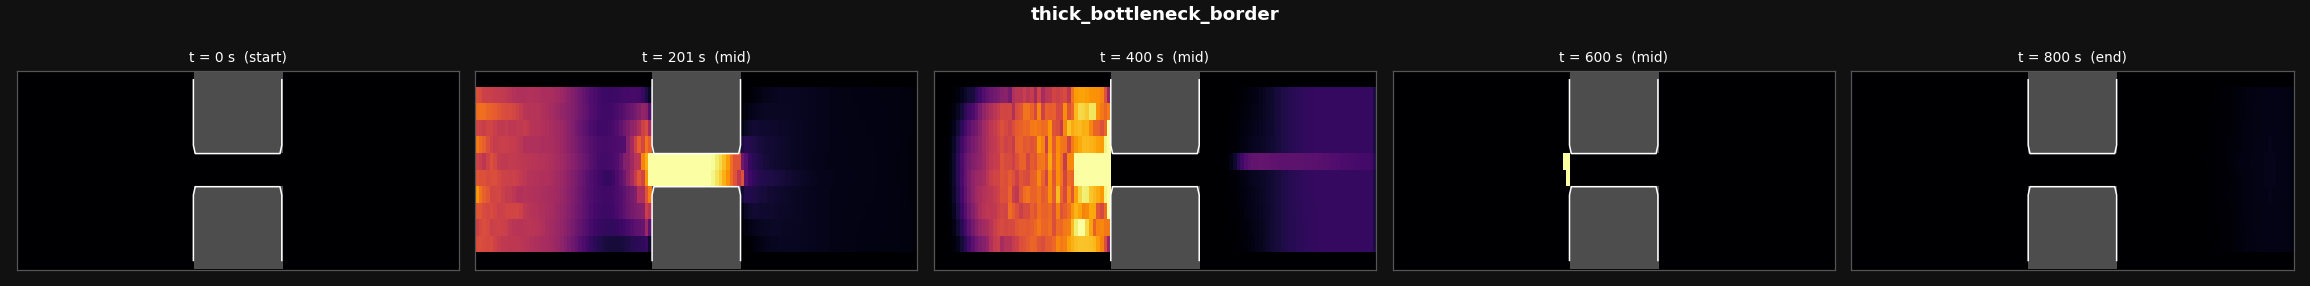

  thick_bottleneck_border    -> 6 files in C:\Users\giuli\Downloads\marathon_snapshots

  Obstacle: WIDE_BOTTLENECK_BORDER
Mesh generated: Nx=120, Ny=12, hx=1.6667, hy=1.6667
  t=    0 s   mass=    0 ped   maxρ=0.00   [Wave 1 – Elite (~40 runners)]
  t=   60 s   mass=  121 ped   maxρ=0.34   [Wave 2 – Fast sub-3h (~490 r]
  t=  120 s   mass=  353 ped   maxρ=0.36   [Gap — next wave in 10 s]
  t=  180 s   mass=  669 ped   maxρ=0.79   [Wave 3 – Intermediate (~960 ]
  t=  240 s   mass=  969 ped   maxρ=0.79   [Gap — next wave in 10 s]
  t=  300 s   mass= 1277 ped   maxρ=1.24   [Wave 4 – Slow / walkers (~13]
  t=  361 s   mass= 1594 ped   maxρ=1.43   [Wave 4 – Slow / walkers (~13]
  t=  420 s   mass= 1368 ped   maxρ=0.73   [All waves released — drainin]
  t=  480 s   mass=  801 ped   maxρ=0.78   [All waves released — drainin]
  t=  540 s   mass=  121 ped   maxρ=0.61   [All waves released — drainin]
  Corridor empty at t = 555 s
  Done: 279 frames in 40 s


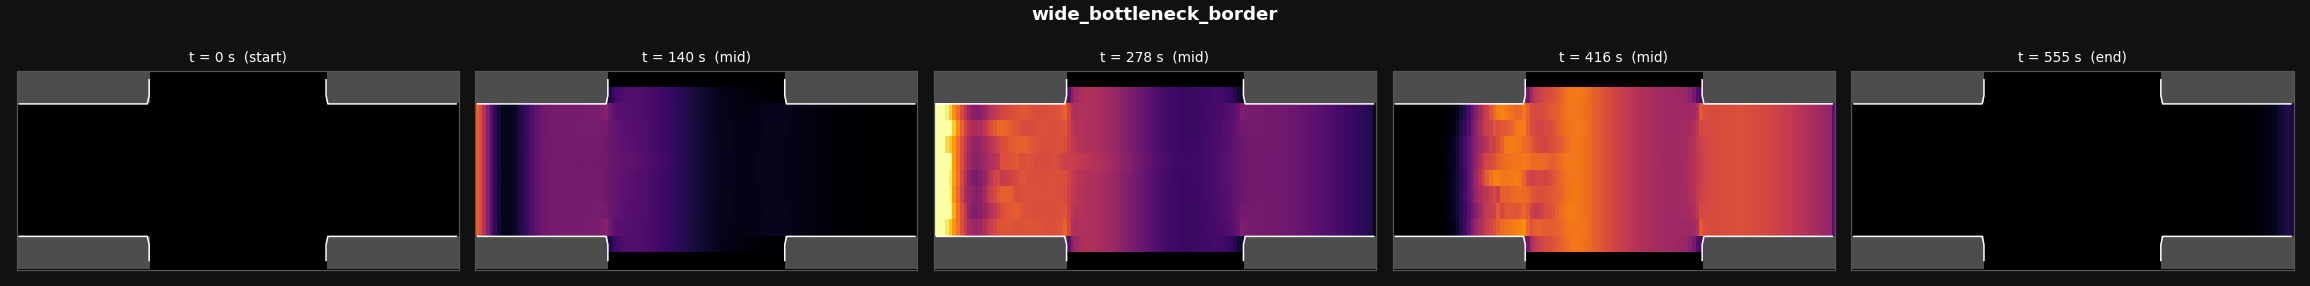

  wide_bottleneck_border     -> 6 files in C:\Users\giuli\Downloads\marathon_snapshots

  Obstacle: THICK_MIDDLE_BLOCK
Mesh generated: Nx=120, Ny=12, hx=1.6667, hy=1.6667
  t=    0 s   mass=    0 ped   maxρ=0.00   [Wave 1 – Elite (~40 runners)]
  t=   60 s   mass=  151 ped   maxρ=0.34   [Wave 2 – Fast sub-3h (~490 r]
  t=  120 s   mass=  442 ped   maxρ=0.97   [Gap — next wave in 10 s]
  t=  180 s   mass=  837 ped   maxρ=2.31   [Wave 3 – Intermediate (~960 ]
  t=  240 s   mass= 1214 ped   maxρ=2.28   [Gap — next wave in 10 s]
  t=  300 s   mass= 1562 ped   maxρ=6.00   [Wave 4 – Slow / walkers (~13]
  t=  361 s   mass= 1729 ped   maxρ=6.00   [Wave 4 – Slow / walkers (~13]
  t=  420 s   mass=  822 ped   maxρ=6.00   [All waves released — drainin]
  t=  480 s   mass=  134 ped   maxρ=6.00   [All waves released — drainin]
  t=  540 s   mass=   38 ped   maxρ=6.00   [All waves released — drainin]
  t=  600 s   mass=   33 ped   maxρ=0.72   [All waves released — drainin]
  t=  660 s   mass=   32 

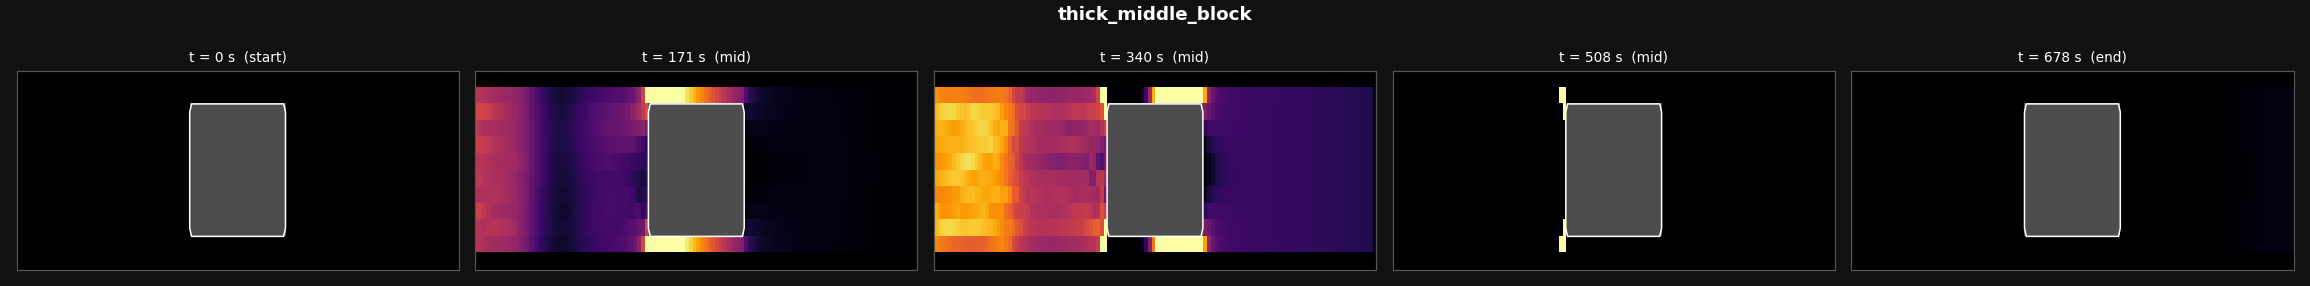

  thick_middle_block         -> 6 files in C:\Users\giuli\Downloads\marathon_snapshots

  Obstacle: TRIANGULAR_POINT_LEFT
Mesh generated: Nx=120, Ny=12, hx=1.6667, hy=1.6667
  t=    0 s   mass=    0 ped   maxρ=0.00   [Wave 1 – Elite (~40 runners)]
  t=   60 s   mass=  151 ped   maxρ=0.34   [Wave 2 – Fast sub-3h (~490 r]
  t=  120 s   mass=  442 ped   maxρ=0.34   [Gap — next wave in 10 s]
  t=  180 s   mass=  836 ped   maxρ=0.76   [Wave 3 – Intermediate (~960 ]
  t=  240 s   mass= 1212 ped   maxρ=0.83   [Gap — next wave in 10 s]
  t=  300 s   mass= 1600 ped   maxρ=1.35   [Wave 4 – Slow / walkers (~13]
  t=  361 s   mass= 2002 ped   maxρ=1.39   [Wave 4 – Slow / walkers (~13]
  t=  420 s   mass= 1729 ped   maxρ=2.30   [All waves released — drainin]
  t=  480 s   mass= 1152 ped   maxρ=1.02   [All waves released — drainin]
  t=  540 s   mass=  509 ped   maxρ=0.48   [All waves released — drainin]
  Corridor empty at t = 594 s
  Done: 298 frames in 38 s


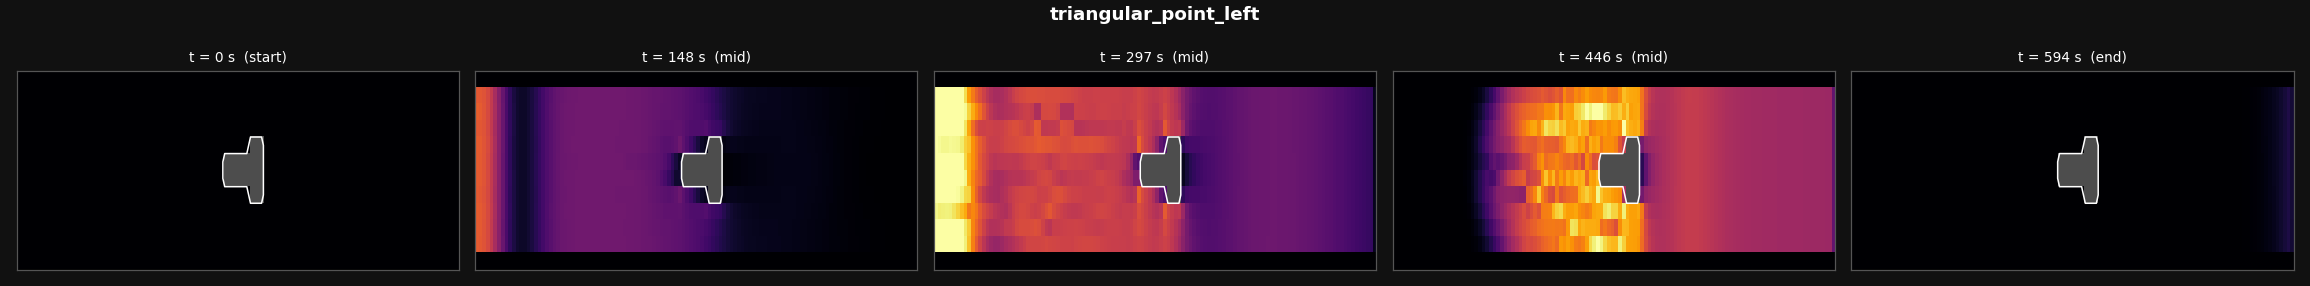

  triangular_point_left      -> 6 files in C:\Users\giuli\Downloads\marathon_snapshots

  Obstacle: TRIANGULAR_POINT_RIGHT
Mesh generated: Nx=120, Ny=12, hx=1.6667, hy=1.6667
  t=    0 s   mass=    0 ped   maxρ=0.00   [Wave 1 – Elite (~40 runners)]
  t=   60 s   mass=  151 ped   maxρ=0.34   [Wave 2 – Fast sub-3h (~490 r]
  t=  120 s   mass=  442 ped   maxρ=0.34   [Gap — next wave in 10 s]
  t=  180 s   mass=  836 ped   maxρ=0.75   [Wave 3 – Intermediate (~960 ]
  t=  240 s   mass= 1212 ped   maxρ=0.80   [Gap — next wave in 10 s]
  t=  300 s   mass= 1600 ped   maxρ=1.29   [Wave 4 – Slow / walkers (~13]
  t=  361 s   mass= 2002 ped   maxρ=1.42   [Wave 4 – Slow / walkers (~13]
  t=  420 s   mass= 1631 ped   maxρ=6.00   [All waves released — drainin]
  t=  480 s   mass=  786 ped   maxρ=6.00   [All waves released — drainin]
  t=  540 s   mass=  276 ped   maxρ=5.22   [All waves released — drainin]
  t=  600 s   mass=   33 ped   maxρ=0.06   [All waves released — drainin]
  Corridor empty at t

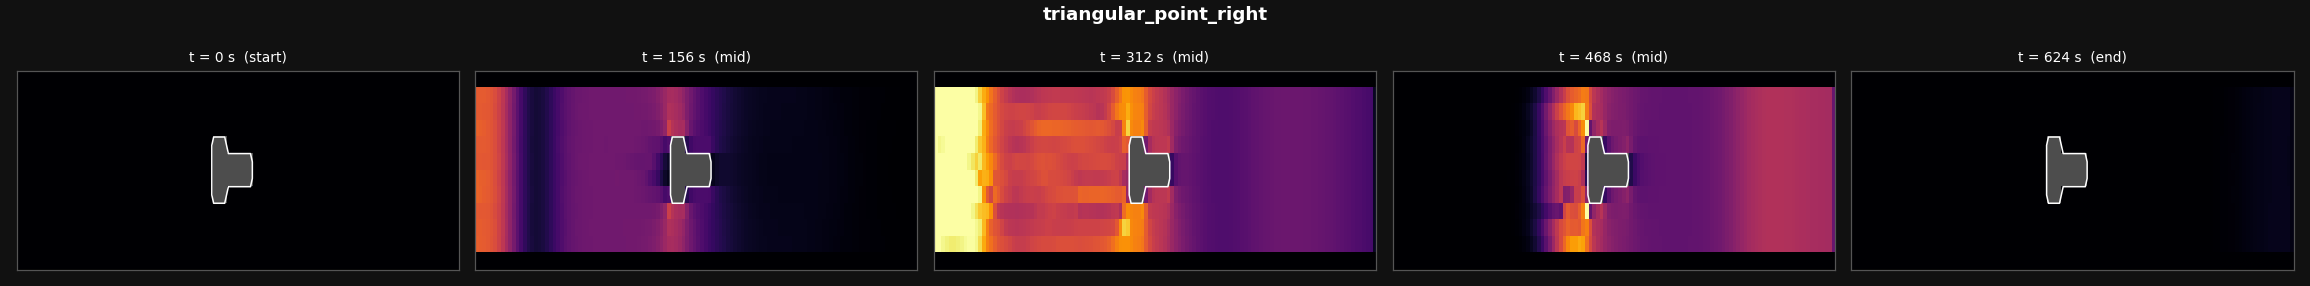

  triangular_point_right     -> 6 files in C:\Users\giuli\Downloads\marathon_snapshots

  Obstacle: STUPID_VALIDATION
Mesh generated: Nx=120, Ny=12, hx=1.6667, hy=1.6667
  t=    0 s   mass=    0 ped   maxρ=0.00   [Wave 1 – Elite (~40 runners)]
  t=   60 s   mass=  151 ped   maxρ=0.34   [Wave 2 – Fast sub-3h (~490 r]
  t=  120 s   mass=  442 ped   maxρ=0.39   [Gap — next wave in 10 s]
  t=  180 s   mass=  837 ped   maxρ=0.86   [Wave 3 – Intermediate (~960 ]
  t=  240 s   mass= 1212 ped   maxρ=0.90   [Gap — next wave in 10 s]
  t=  300 s   mass= 1606 ped   maxρ=1.68   [Wave 4 – Slow / walkers (~13]
  t=  361 s   mass= 2023 ped   maxρ=1.86   [Wave 4 – Slow / walkers (~13]
  t=  420 s   mass= 1426 ped   maxρ=6.00   [All waves released — drainin]
  t=  480 s   mass=  611 ped   maxρ=6.00   [All waves released — drainin]
  t=  540 s   mass=  221 ped   maxρ=5.67   [All waves released — drainin]
  t=  600 s   mass=   57 ped   maxρ=0.07   [All waves released — drainin]
  Corridor empty at t = 63

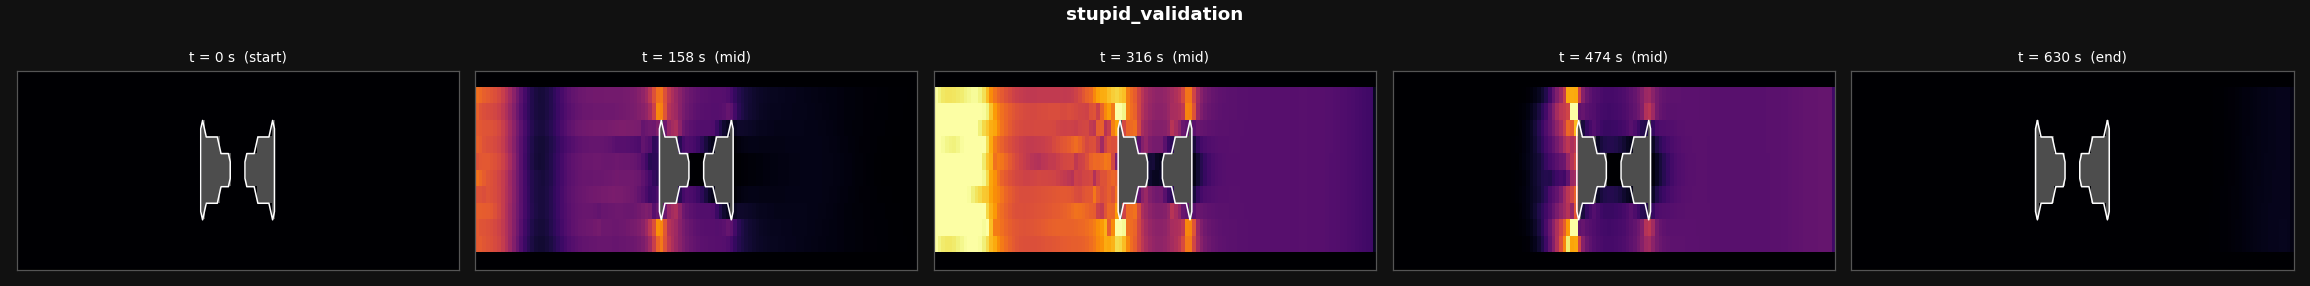

  stupid_validation          -> 6 files in C:\Users\giuli\Downloads\marathon_snapshots


In [21]:
import os
from IPython.display import Image, display

# Where snapshots are written. Change this if your username/folder differs.
SNAP_DIR = r'C:\Users\giuli\Downloads\marathon_snapshots'

# inferno, but obstacle (NaN) cells are drawn grey instead of blending into black.
OBST_CMAP = plt.get_cmap('inferno').copy()
OBST_CMAP.set_bad('#4d4d4d')


def _draw_density(ax, rho, obs, vmax):
    """imshow the density with obstacle cells greyed out + white outline."""
    data = rho.copy().astype(float); data[obs] = np.nan
    im = ax.imshow(data.T, extent=[0, LX, 0, LY], origin='lower',
                   cmap=OBST_CMAP, vmin=0, vmax=vmax, aspect='auto')
    # outline the obstacle so its shape is always visible
    Nx, Ny = obs.shape
    xc = (np.arange(Nx) + 0.5) * LX / Nx
    yc = (np.arange(Ny) + 0.5) * LY / Ny
    if obs.any():
        ax.contour(xc, yc, obs.T.astype(float), levels=[0.5],
                   colors='white', linewidths=1.0)
    return im


def save_snapshots(frames, obs, name, outdir=SNAP_DIR, n_middle=3, show=True):
    """Save start + n_middle + end density snapshots for one geometry.

    Obstacle cells render grey with a white outline (visible at every time,
    including t=0 when the corridor is empty). Files go to `outdir`; the strip
    is also embedded inline via IPython.display.Image so it shows under the
    Agg backend set in the Imports cell. Returns the written paths (strip first).
    """
    os.makedirs(outdir, exist_ok=True)
    idxs = np.unique(np.linspace(0, len(frames) - 1, n_middle + 2).round().astype(int))

    # Shared colour range (same recipe as make_animation)
    all_rho  = np.concatenate([r[~obs].ravel() for _, r in frames])
    occupied = all_rho[all_rho > 0.02]
    vmax     = max(float(np.percentile(occupied, 97)) if len(occupied) else 1.0, 0.3)

    # (a) combined strip ------------------------------------------------------
    fig, axes = plt.subplots(1, len(idxs), figsize=(4.2 * len(idxs), 2.6))
    fig.patch.set_facecolor('#111111')
    for ax, k in zip(np.atleast_1d(axes), idxs):
        t, rho = frames[k]
        ax.set_facecolor('black')
        _draw_density(ax, rho, obs, vmax)
        tag = 'start' if k == idxs[0] else ('end' if k == idxs[-1] else 'mid')
        ax.set_title(f't = {t:.0f} s  ({tag})', color='white', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_edgecolor('#555555')
    fig.suptitle(name, color='white', fontweight='bold', fontsize=12)
    plt.tight_layout()
    strip = os.path.join(outdir, f'snapshots_{name}.png')
    fig.savefig(strip, dpi=110, facecolor='#111111'); plt.close(fig)
    paths = [strip]

    # (b) individual frames (one file each) -----------------------------------
    for k in idxs:
        t, rho = frames[k]
        fig, ax = plt.subplots(figsize=(11, 2.4)); fig.patch.set_facecolor('#111111')
        ax.set_facecolor('black')
        im = _draw_density(ax, rho, obs, vmax)
        ax.set_title(f'{name} - t = {t:.0f} s', color='white', fontsize=10)
        ax.set_xlabel('x [m]', color='white'); ax.set_ylabel('y [m]', color='white')
        ax.tick_params(colors='white')
        cb = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
        cb.set_label('rho [ped/m2]', color='white')
        plt.setp(cb.ax.get_yticklabels(), color='white')
        plt.tight_layout()
        p = os.path.join(outdir, f'{name}_t{int(round(t)):04d}.png')
        fig.savefig(p, dpi=110, facecolor='#111111'); plt.close(fig)
        paths.append(p)

    if show:
        display(Image(filename=strip))   # inline render (works under Agg)
    return paths


SIX_GEOMETRIES = [
    'thick_bottleneck_border', 'wide_bottleneck_border', 'thick_middle_block',
    'triangular_point_left',   'triangular_point_right', 'stupid_validation',
]

snapshot_files = {}
for name in SIX_GEOMETRIES:
    frames, obs, h = run_marathon_sim(name, frame_dt=2.0)
    snapshot_files[name] = save_snapshots(frames, obs, name)
    print(f"  {name:26s} -> {len(snapshot_files[name])} files in {SNAP_DIR}")


---
## Part 3 – Comparison with the Payne–Whitham model (`oneroom_new_6_inflow`)

To compare the Hughes model against the Payne–Whitham notebook on a level field, this
part re-runs the Hughes solver on the **exact same setup** as that notebook:

| Item | Value (matched to the PW notebook) |
|------|-------------------------------------|
| Domain | 20 m × 10 m single room |
| Inflow | left **door** at y ∈ [3, 7] |
| Outflow | right **door** at y ∈ [2, 8] (6 m wide) |
| Demand | 3 inflow waves of (ρ_in, v_in): (2.0, 1.5)→(3.5, 1.0)→(5.0, 0.5) |
| Equilibrium speed | v_eq(ρ) = v_max·exp(−α (ρ/ρ_max)²), v_max=1.3, α=2, ρ_max=6 |
| Horizon | t = 30 s |
| Colormap | **Reds**, vmin=0, vmax=ρ_max=6 |

Only the **model dynamics** differ: Hughes routes mass instantaneously along −∇φ at the
equilibrium speed, whereas Payne–Whitham carries a momentum equation that relaxes toward it.
Everything reused below (`solve_phi_fast_sweeping_first_order`, `compute_godunov_gradient`,
`compute_flux_from_eq26`, `compute_drho_dt`) is the base-notebook machinery.

In [22]:
# ── Parameters matched to oneroom_new_6_inflow (Payne-Whitham) ───────────────
LX_R, LY_R   = 20.0, 10.0
NX_R, NY_R   = 80, 40            # h = 0.25 m
RHO_MAX_R    = 6.0
V_MAX_R      = 1.3
ALPHA_R      = 2.0
INFLOW_DOOR  = (3.0, 7.0)        # left inlet
OUTFLOW_DOOR = (2.0, 8.0)        # right exit (door_w = 6, centred y=5)
T_FINAL_R    = 30.0

# Three inflow waves: (t0, t1, rho_in [ped/m2], v_in [m/s]) -- matches that notebook
ROOM_WAVES = [
    (0.0,  4.0, 2.0, 1.5),
    (8.0, 12.0, 3.5, 1.0),
    (18.0, 20.0, 5.0, 0.5),
]

def room_inflow(t):
    """(rho_in, v_in) for the active wave at time t; (0,0) between/after waves."""
    for t0, t1, r, v in ROOM_WAVES:
        if t0 <= t < t1:
            return r, v
    return 0.0, 0.0

def compute_speed_pw(rho, rho_max=RHO_MAX_R, v_max=V_MAX_R, alpha=ALPHA_R, eps=1e-8):
    """Exponential equilibrium speed v_eq(rho)=v_max*exp(-alpha*(rho/rho_max)^2),
    identical to get_velocity() in the Payne-Whitham notebook."""
    rho_s = np.clip(rho, 0.0, rho_max * 1.5)
    return np.maximum(v_max * np.exp(-alpha * (rho_s / rho_max) ** 2), eps)


# ── Six geometries — copied verbatim from the PW notebook (its domain_configs) ─
def _rect(X, Y, cx, cy, w, h):
    return (np.abs(X - cx) <= w / 2.0) & (np.abs(Y - cy) <= h / 2.0)

def _tri(X, Y, p1, p2, p3):
    (x1, y1), (x2, y2), (x3, y3) = p1, p2, p3
    def sgn(ax, ay, bx, by):
        return (X - bx) * (ay - by) - (ax - bx) * (Y - by)
    d1 = sgn(x1, y1, x2, y2); d2 = sgn(x2, y2, x3, y3); d3 = sgn(x3, y3, x1, y1)
    return ~(((d1 < 0) | (d2 < 0) | (d3 < 0)) & ((d1 > 0) | (d2 > 0) | (d3 > 0)))

ROOM_GEOMETRIES = {
    'thick_bottleneck_border': lambda X, Y: _rect(X, Y, 10, 8, 4, 4) | _rect(X, Y, 10, 2, 4, 4),
    'wide_bottleneck_border' : lambda X, Y: _rect(X, Y, 10, 9, 8, 2) | _rect(X, Y, 10, 1, 8, 2),
    'thick_middle_block'     : lambda X, Y: _rect(X, Y, 10, 5, 5, 3.6),
    'triangular_point_left'  : lambda X, Y: _tri(X, Y, (8, 5), (12, 3), (12, 7)),
    'triangular_point_right' : lambda X, Y: _tri(X, Y, (12, 5), (8, 7), (8, 3)),
    'stupid_validation'      : lambda X, Y: (_tri(X, Y, (7, 3), (10, 1.5), (10, 5)) |
                                             _tri(X, Y, (7, 7), (10, 5), (10, 8.5))),
}


def build_room_boundaries(Nx, Ny, obs, x, y, inflow_door=INFLOW_DOOR, outflow_door=OUTFLOW_DOOR):
    """Left-door inflow, right-door outflow, walls elsewhere + obstacle interior.
    Same (gamma_i, gamma_d, gamma_h) format used by every base-notebook function."""
    yl, yh   = inflow_door
    yo0, yo1 = outflow_door
    gi, gd, gh = [], [], []
    for j in range(Ny):
        if (yl <= y[j] <= yh) and not obs[0, j]:      gi.append((0, j))
        if (yo0 <= y[j] <= yo1) and not obs[Nx-1, j]: gd.append((Nx-1, j))
    for i in range(Nx):
        if not obs[i, 0]:     gh.append((i, 0))
        if not obs[i, Ny-1]:  gh.append((i, Ny-1))
    gh.extend(list(zip(*np.where(obs))))
    return gi, gd, gh


### 3.1 Geometry preview (the 6 comparison rooms)

Mesh generated: Nx=80, Ny=40, hx=0.2500, hy=0.2500


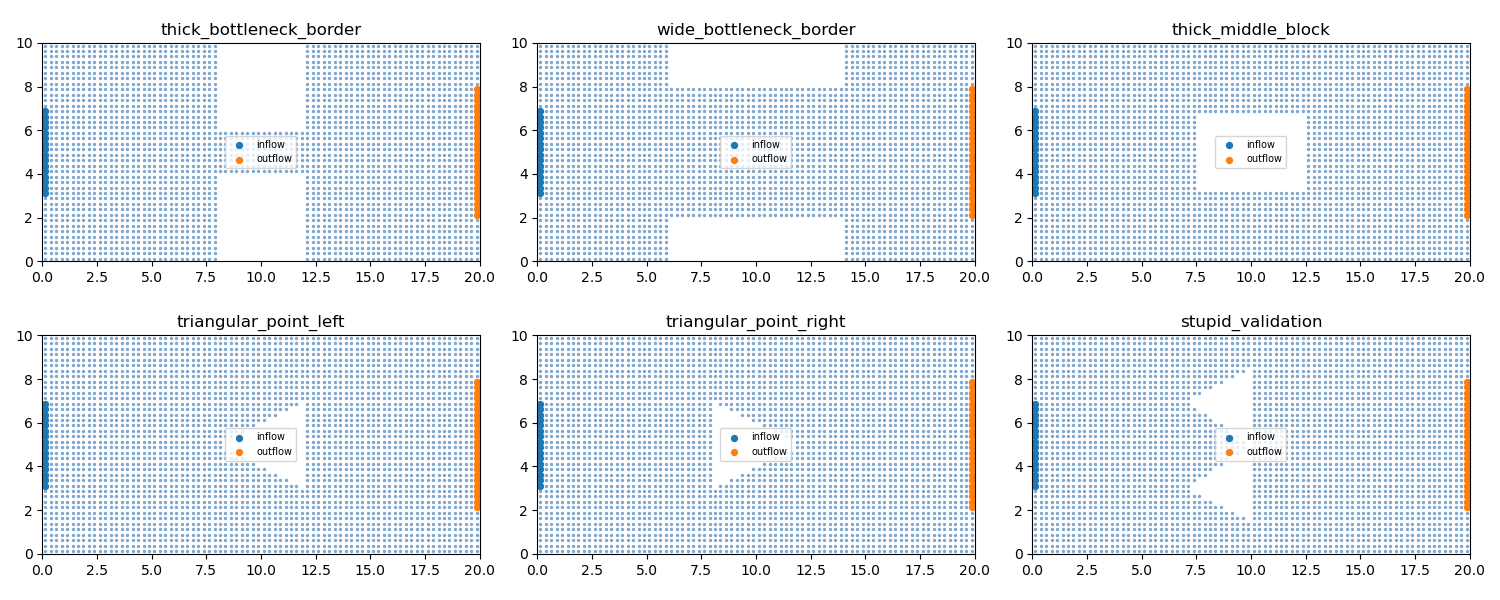

In [23]:
import os
from IPython.display import Image, display

ROOM_OUT = r'C:\Users\giuli\Downloads\hughes_payne_comparison'
os.makedirs(ROOM_OUT, exist_ok=True)

def preview_room_geometries(outdir=ROOM_OUT):
    x, y, X, Y, h = define_mesh(NX_R, NY_R, Lx=LX_R, Ly=LY_R)
    fig, axes = plt.subplots(2, 3, figsize=(15, 6))
    for ax, (name, fn) in zip(axes.ravel(), ROOM_GEOMETRIES.items()):
        obs = fn(X, Y)
        gi, gd, gh = build_room_boundaries(NX_R, NY_R, obs, x, y)
        walk = ~obs
        ax.scatter(X[walk], Y[walk], s=2, color='#7fa8d0')
        gi = np.array(gi); gd = np.array(gd)
        if len(gi): ax.scatter(x[gi[:, 0]], y[gi[:, 1]], s=18, color='tab:blue',   label='inflow')
        if len(gd): ax.scatter(x[gd[:, 0]], y[gd[:, 1]], s=18, color='tab:orange', label='outflow')
        ax.set_title(name); ax.set_xlim(0, LX_R); ax.set_ylim(0, LY_R)
        ax.set_aspect('equal'); ax.legend(loc='center', fontsize=7)
    plt.tight_layout()
    p = os.path.join(outdir, 'room_geometry_preview.png')
    fig.savefig(p, dpi=100); plt.close(fig)
    display(Image(filename=p))

preview_room_geometries()


### 3.2 Room solver (reuses the base eikonal / gradient / flux / RK3 blocks)

`compute_L_room` and `step_RK3_room` mirror `compute_L_marathon` / `step_RK3_marathon`
(Part 2) but use the **exponential** equilibrium speed and the door inflow flux
ρ_in·v_in. Every spatial operator they call is unchanged from Part 1.

In [24]:
def compute_L_room(rho, Nx, Ny, h, gamma_i, gamma_d, gamma_h, obstacle_mask, inflow_flux):
    u = compute_speed_pw(rho)
    c = 1.0 / np.maximum(u, 1e-4)            # cost = 1/v_eq  (same as PW get_cost)
    c[obstacle_mask] = 1e6
    phi = solve_phi_fast_sweeping_first_order(c, gamma_d, gamma_h, Nx, Ny, h)
    grad_x, grad_y = compute_godunov_gradient(phi, h)
    f1, f2 = compute_flux_from_eq26(rho, u, c, grad_x, grad_y)
    f1[obstacle_mask] = 0.0
    f2[obstacle_mask] = 0.0
    return compute_drho_dt(rho, f1, f2, h, gamma_i, gamma_d, gamma_h,
                           inflow_flux=inflow_flux, obstacle_mask=obstacle_mask)


def step_RK3_room(rho_n, Nx, Ny, h, dt, gamma_i, gamma_d, gamma_h, obstacle_mask, inflow_flux):
    def L(r):
        return compute_L_room(r, Nx, Ny, h, gamma_i, gamma_d, gamma_h, obstacle_mask, inflow_flux)
    def clip(r):
        r = np.clip(r, 0, RHO_MAX_R - 1e-8); r[obstacle_mask] = 0.0; return r
    d0 = L(rho_n);  r1 = clip(rho_n + dt*d0)
    d1 = L(r1);     r2 = clip(0.75*rho_n + 0.25*(r1 + dt*d1))
    d2 = L(r2)
    return clip((1/3)*rho_n + (2/3)*(r2 + dt*d2))


def run_room_sim(name, Nx=NX_R, Ny=NY_R, t_final=T_FINAL_R, snapshot_dt=0.5):
    """Hughes solver on the PW room — returns full result dict with frames AND metrics.

    The result dict contains:
      frames, obs, h, x, y           — for plotting
      ts, M_d, M_ci, M_co            — mass time-series (mirrors PedestrianCounter)
      rho_safe_series, speed_series   — instantaneous congestion / speed-loss
      T_av, C_cong, C_speed, loss     — loss-function terms (same formula as PW)
      C_left, M_left, total_people
    """
    print(f"  running {name} ...")
    x, y, X, Y, h = define_mesh(Nx, Ny, Lx=LX_R, Ly=LY_R)
    obs = ROOM_GEOMETRIES[name](X, Y)
    gamma_i, gamma_d, gamma_h = build_room_boundaries(Nx, Ny, obs, x, y)
    cell_area  = h * h
    inflow_len = len(gamma_i) * h

    rho = np.zeros((Nx, Ny)); t = 0.0; frames = []; next_frame = 0.0
    ts = []; M_d = []; M_ci = []; M_co = []
    rho_safe_series = []; speed_series = []
    cum_in = 0.0; cum_out = 0.0

    while t < t_final - 1e-9:
        if t >= next_frame - 1e-9:
            frames.append((round(t, 3), rho.copy())); next_frame += snapshot_dt

        rho_in, v_in = room_inflow(t)
        dt_s = min(0.4 * h / max(V_MAX_R, 0.3), t_final - t, snapshot_dt)

        old_mass = float(np.sum(rho) * cell_area)
        cum_in  += rho_in * v_in * inflow_len * dt_s
        rho      = step_RK3_room(rho, Nx, Ny, h, dt_s, gamma_i, gamma_d, gamma_h, obs, rho_in * v_in)
        new_mass = float(np.sum(rho) * cell_area)
        cum_out += max(0.0, old_mass + rho_in * v_in * inflow_len * dt_s - new_mass)
        t += dt_s

        ts.append(round(t, 3));  M_d.append(new_mass)
        M_ci.append(cum_in);     M_co.append(cum_out)

        rho_w  = rho[~obs]
        v_eq_w = compute_speed_pw(rho_w)
        rho_safe_series.append(float(np.sum(np.maximum(rho_w - 3.5, 0.0) ** 2) * cell_area))
        speed_series.append(   float(np.sum(rho_w * (V_MAX_R - v_eq_w) ** 2) * cell_area))

    frames.append((round(t, 3), rho.copy()))
    ts = np.array(ts); M_d = np.array(M_d); M_ci = np.array(M_ci); M_co = np.array(M_co)
    rho_safe_series = np.array(rho_safe_series); speed_series = np.array(speed_series)

    total_people = max(float(M_ci[-1]), 1e-12)
    T_av   = float(np.trapezoid(M_d, ts)) / total_people
    C_cong = float(np.trapezoid(rho_safe_series, ts)) / total_people
    C_speed= float(np.trapezoid(speed_series,    ts)) / total_people
    M_left = float(M_d[-1]); C_left = M_left / total_people
    loss   = T_av + 0.05 * C_cong + 0.05 * C_speed

    return dict(name=name, frames=frames, obs=obs, h=h, x=x, y=y,
                ts=ts, M_d=M_d, M_ci=M_ci, M_co=M_co,
                rho_safe_series=rho_safe_series, speed_series=speed_series,
                T_av=T_av, C_cong=C_cong, C_speed=C_speed,
                C_left=C_left, M_left=M_left, loss=loss, total_people=total_people)


### 3.3 Payne-style plotting (Reds colormap, same vmax)

`plot_room_grid` is the static 8-panel figure at the PW notebook's `plot_times`;
`animate_room` mirrors its `do_animation` (tripcolor → imshow, `Reds`, vmin=0, vmax=ρ_max).
Obstacle cells are left white (as in the PW mesh hole) with a thin grey outline so the
shape stays visible.

In [25]:
ROOM_CMAP = plt.get_cmap('Reds').copy()
ROOM_CMAP.set_bad('white')                 # obstacle (NaN) -> white, like the PW mesh hole
PLOT_TIMES = [0.0, 3.0, 6.0, 9.0, 12.0, 15.0, 22.5, 30.0]


def _draw_room(ax, rho, obs):
    data = rho.copy().astype(float); data[obs] = np.nan
    im = ax.imshow(data.T, extent=[0, LX_R, 0, LY_R], origin='lower',
                   cmap=ROOM_CMAP, vmin=0, vmax=RHO_MAX_R, aspect='equal')
    Nx, Ny = obs.shape
    xc = (np.arange(Nx) + 0.5) * LX_R / Nx
    yc = (np.arange(Ny) + 0.5) * LY_R / Ny
    if obs.any():
        ax.contour(xc, yc, obs.T.astype(float), levels=[0.5], colors='0.5', linewidths=0.8)
    return im


def plot_room_grid(frames, obs, name, times=PLOT_TIMES, outdir=ROOM_OUT, show=True):
    import math
    n = len(times); nc = 4; nr = math.ceil(n / nc)
    fig, axes = plt.subplots(nr, nc, figsize=(4.0 * nc, 2.2 * nr))
    axes = np.atleast_1d(axes).ravel()
    im = None
    for ax, tt in zip(axes, times):
        t, rho = min(frames, key=lambda f: abs(f[0] - tt))
        im = _draw_room(ax, rho, obs)
        ax.set_title(f't = {t:.1f} s', fontsize=9); ax.set_xticks([]); ax.set_yticks([])
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle(f'Hughes model — {name}', fontweight='bold')
    if im is not None:
        fig.colorbar(im, ax=axes.tolist(), fraction=0.012, pad=0.01,
                     label=r'$\rho$ [ped/m$^2$]')
    p = os.path.join(outdir, f'grid_{name}.png')
    fig.savefig(p, dpi=100, bbox_inches='tight'); plt.close(fig)
    if show:
        display(Image(filename=p))
    return p


def animate_room(frames, obs, name, outdir=ROOM_OUT, fps=10):
    """Reds density animation, matching the PW do_animation look. Saves a GIF."""
    fig, ax = plt.subplots(figsize=(8, 4))
    def update(k):
        ax.clear()
        t, rho = frames[k]
        _draw_room(ax, rho, obs)
        ax.set_title(f'Hughes — {name} — density at t = {t:.2f} s')
        ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
        ax.set_xlim(0, LX_R); ax.set_ylim(0, LY_R)
    ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=1000 // fps)
    p = os.path.join(outdir, f'{name}.gif')
    ani.save(p, writer='pillow', fps=fps); plt.close(fig)
    print(f"    saved {p}")
    return p


### 3.4 Run all 6 geometries → snapshot grids (+ optional GIFs)

Set `MAKE_GIFS = True` to also write Reds `.gif` animations next to the grids
(same filenames the PW notebook uses, e.g. `thick_middle_block.gif`).

  running thick_bottleneck_border ...
Mesh generated: Nx=80, Ny=40, hx=0.2500, hy=0.2500


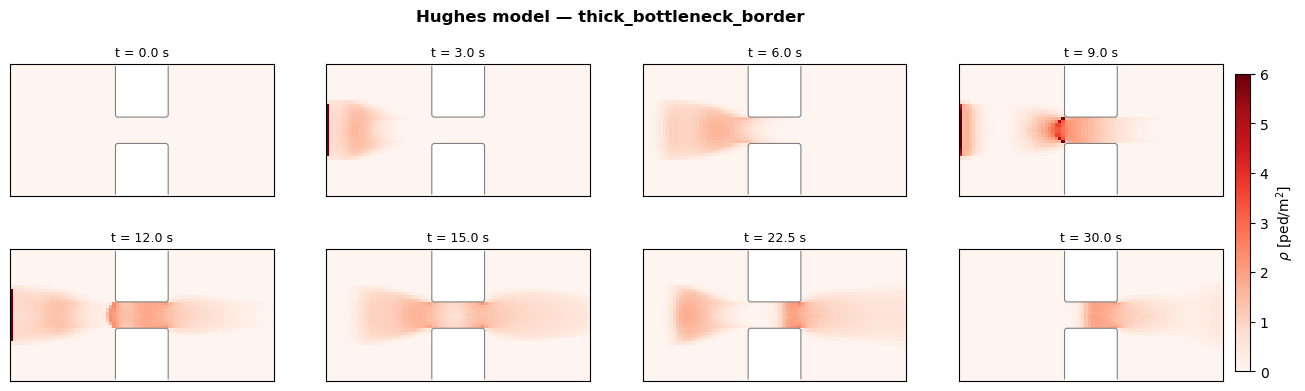

    saved C:\Users\giuli\Downloads\hughes_payne_comparison\thick_bottleneck_border.gif
  running wide_bottleneck_border ...
Mesh generated: Nx=80, Ny=40, hx=0.2500, hy=0.2500


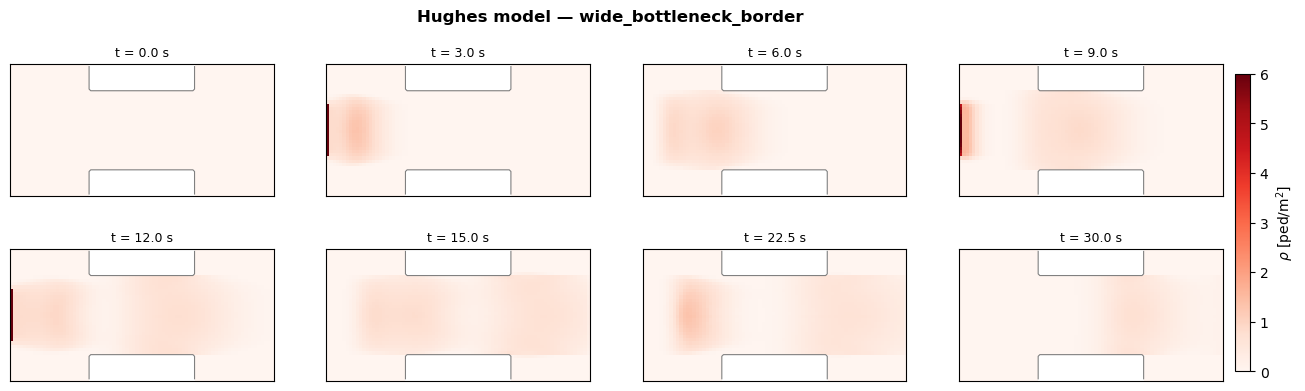

    saved C:\Users\giuli\Downloads\hughes_payne_comparison\wide_bottleneck_border.gif
  running thick_middle_block ...
Mesh generated: Nx=80, Ny=40, hx=0.2500, hy=0.2500


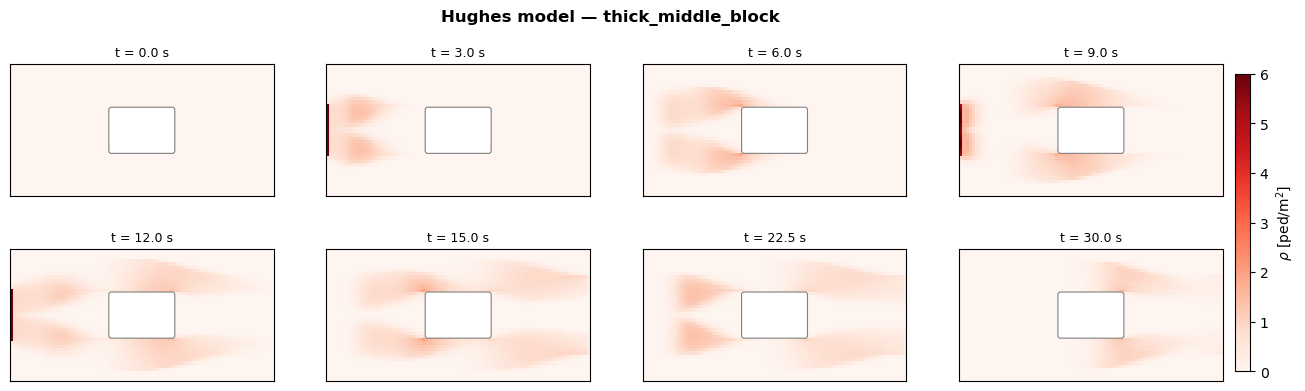

    saved C:\Users\giuli\Downloads\hughes_payne_comparison\thick_middle_block.gif
  running triangular_point_left ...
Mesh generated: Nx=80, Ny=40, hx=0.2500, hy=0.2500


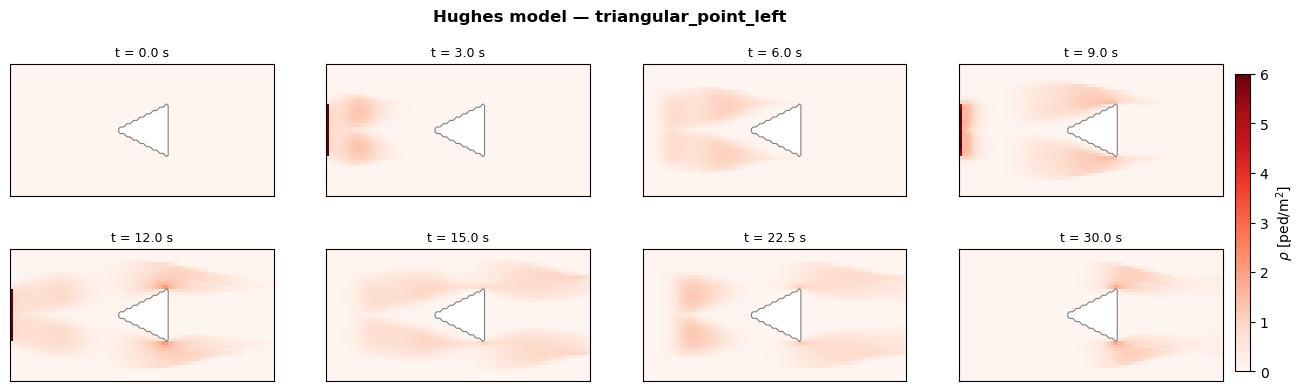

    saved C:\Users\giuli\Downloads\hughes_payne_comparison\triangular_point_left.gif
  running triangular_point_right ...
Mesh generated: Nx=80, Ny=40, hx=0.2500, hy=0.2500


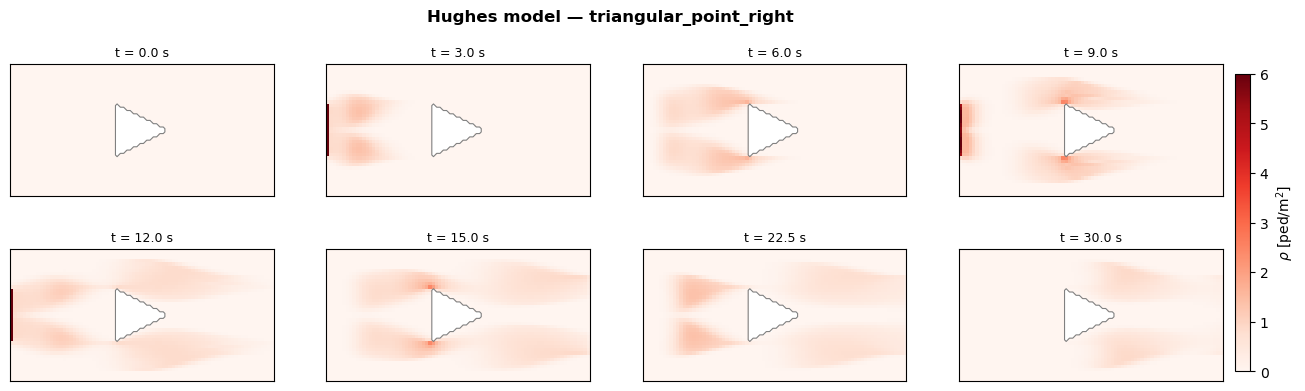

    saved C:\Users\giuli\Downloads\hughes_payne_comparison\triangular_point_right.gif
  running stupid_validation ...
Mesh generated: Nx=80, Ny=40, hx=0.2500, hy=0.2500


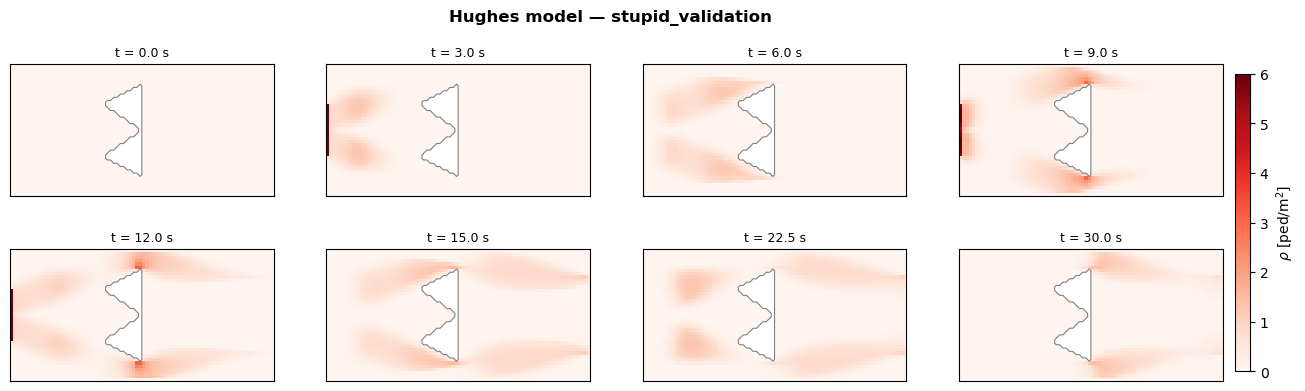

    saved C:\Users\giuli\Downloads\hughes_payne_comparison\stupid_validation.gif

Done. Files in C:\Users\giuli\Downloads\hughes_payne_comparison


In [26]:
MAKE_GIFS = True   # set False to skip GIF rendering (faster)

room_results = {}
for name in ROOM_GEOMETRIES:
    res  = run_room_sim(name)
    grid = plot_room_grid(res['frames'], res['obs'], name)
    gif  = animate_room(res['frames'], res['obs'], name) if MAKE_GIFS else None
    res['grid'] = grid;  res['gif'] = gif
    room_results[name] = res
print(f"\nDone. Files in {ROOM_OUT}")


### 3.5 Graph 1 — Density · Potential · Direction field (3-panel, per geometry)

Mirrors the Payne notebook's `plot_results`: three stacked panels at a chosen
snapshot time.
- **Panel 1 – Density** (`Reds`, 0 → ρ_max=6): crowd distribution at time t.
- **Panel 2 – Potential φ** (`magma`): the eikonal travel-time field; dashed white
  contours show the ρ = 2 and ρ = 4 density iso-lines.
- **Panel 3 – Direction μ** (quiver, `royalblue`): −∇φ/‖∇φ‖, the desired walking
  direction; red dashed iso-lines at ρ = 2 and ρ = 4.

One file per geometry is saved to `ROOM_OUT`; they are also displayed inline.

Mesh generated: Nx=80, Ny=40, hx=0.2500, hy=0.2500


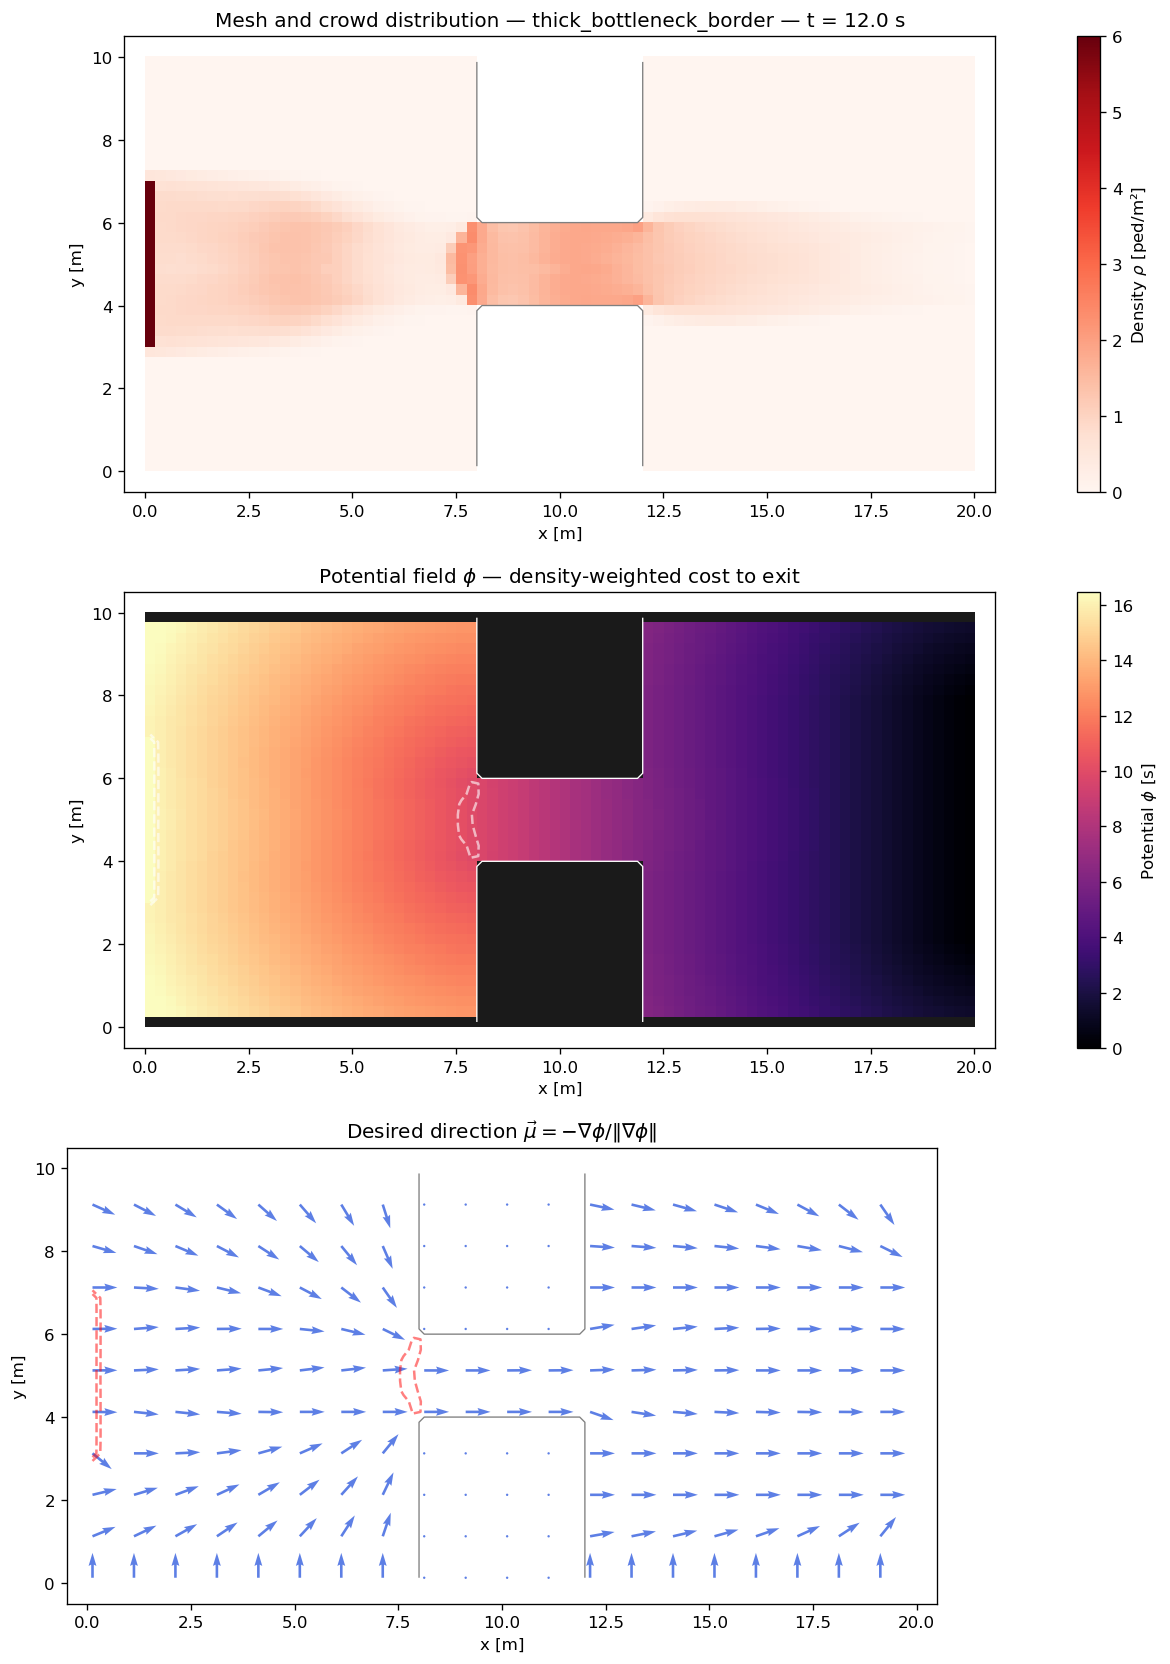

Mesh generated: Nx=80, Ny=40, hx=0.2500, hy=0.2500


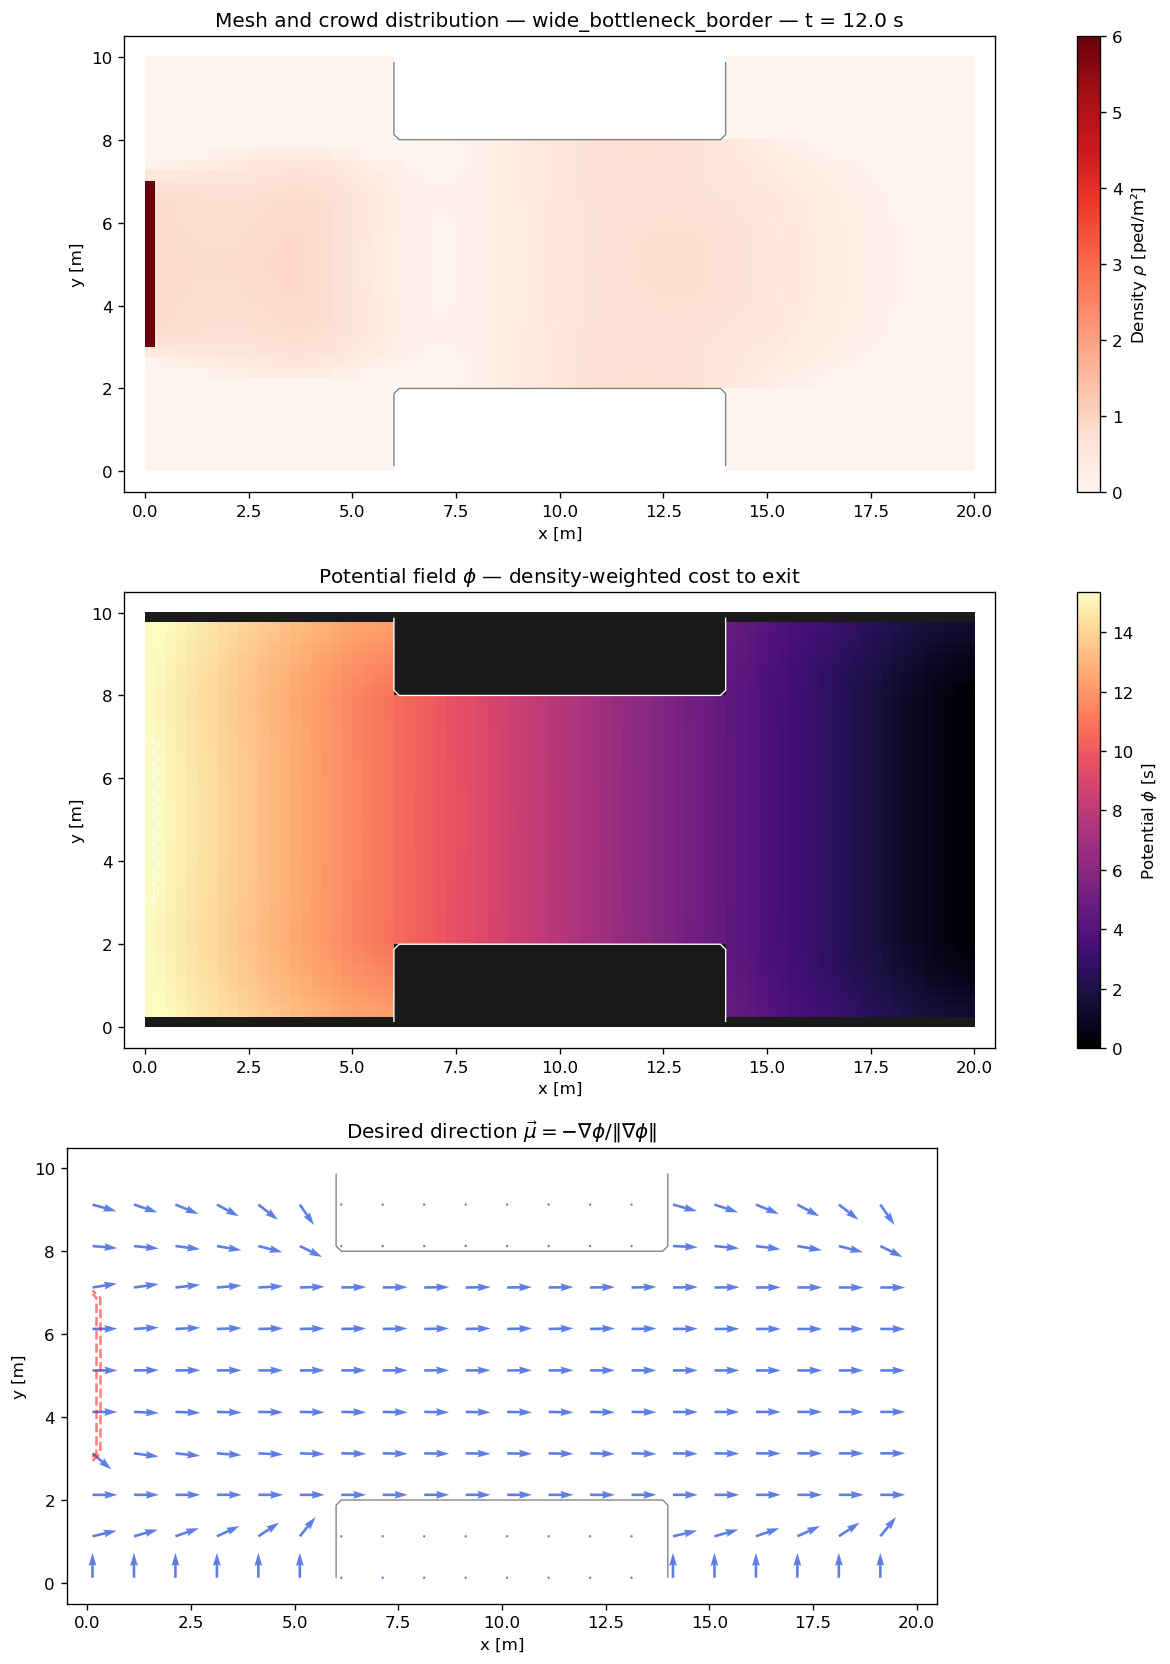

Mesh generated: Nx=80, Ny=40, hx=0.2500, hy=0.2500


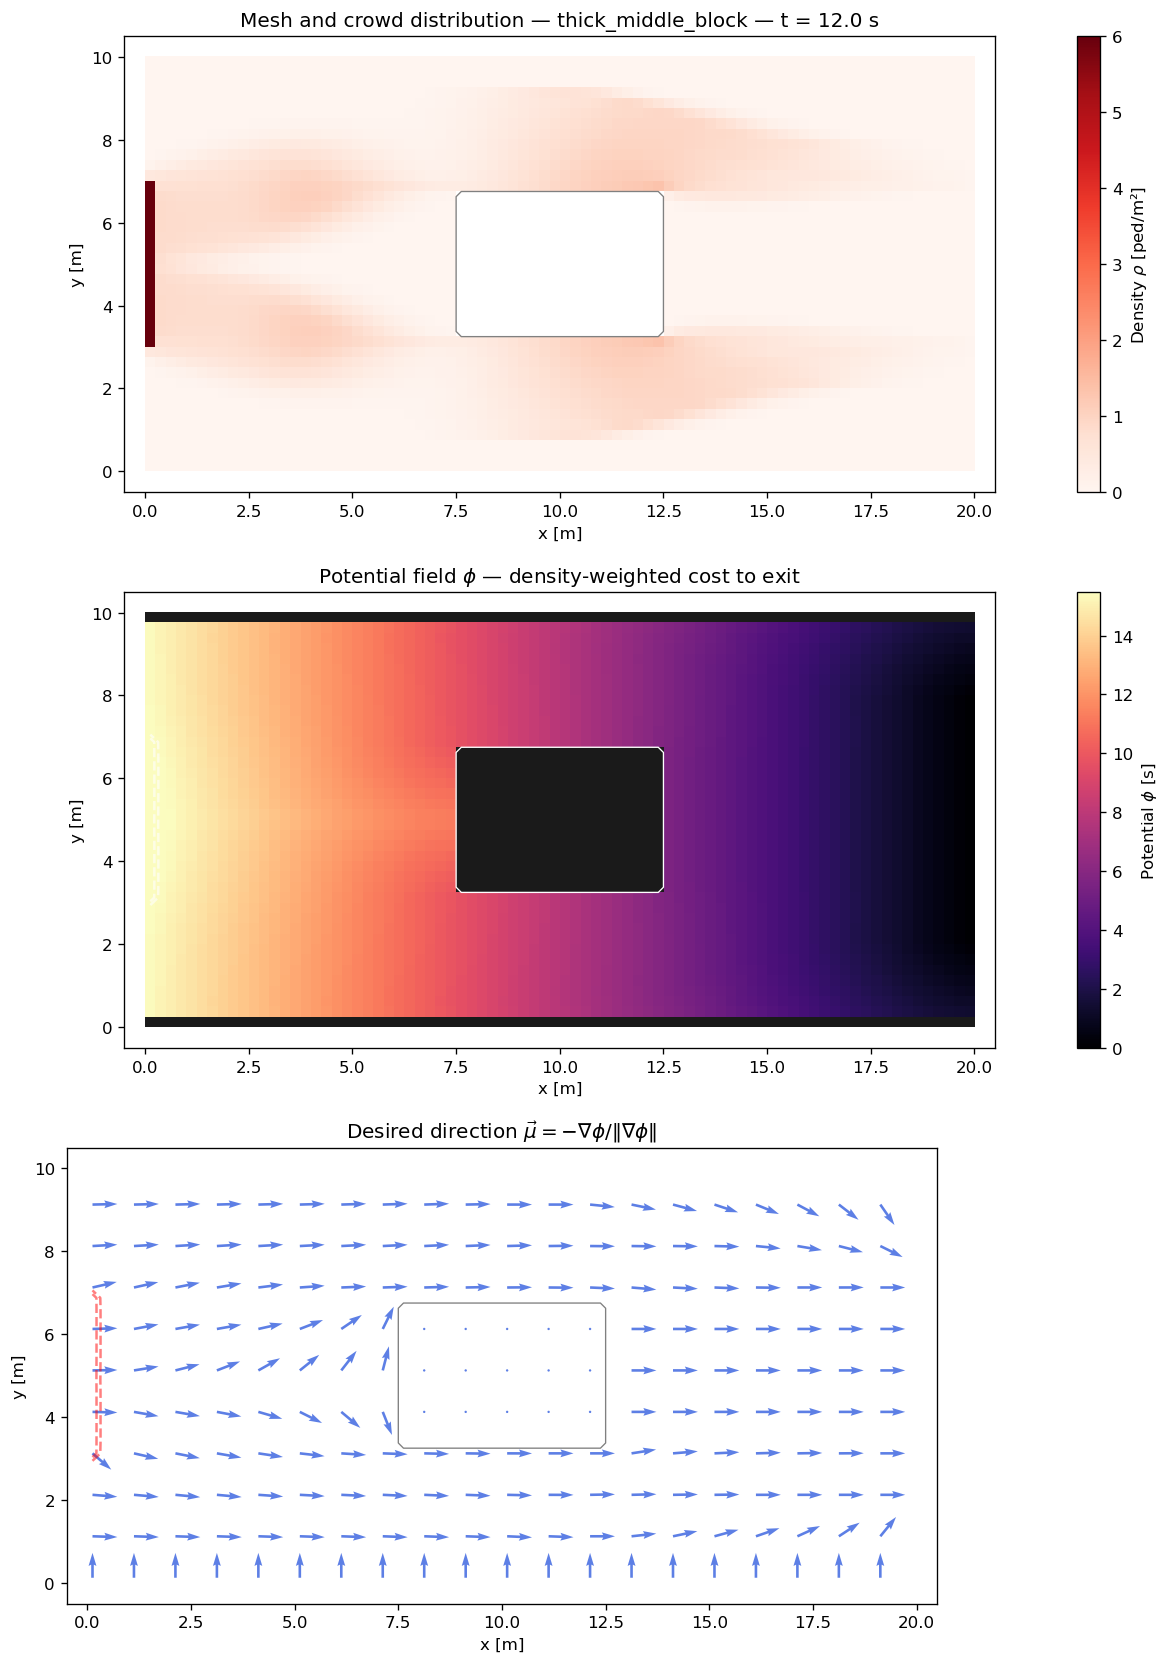

Mesh generated: Nx=80, Ny=40, hx=0.2500, hy=0.2500


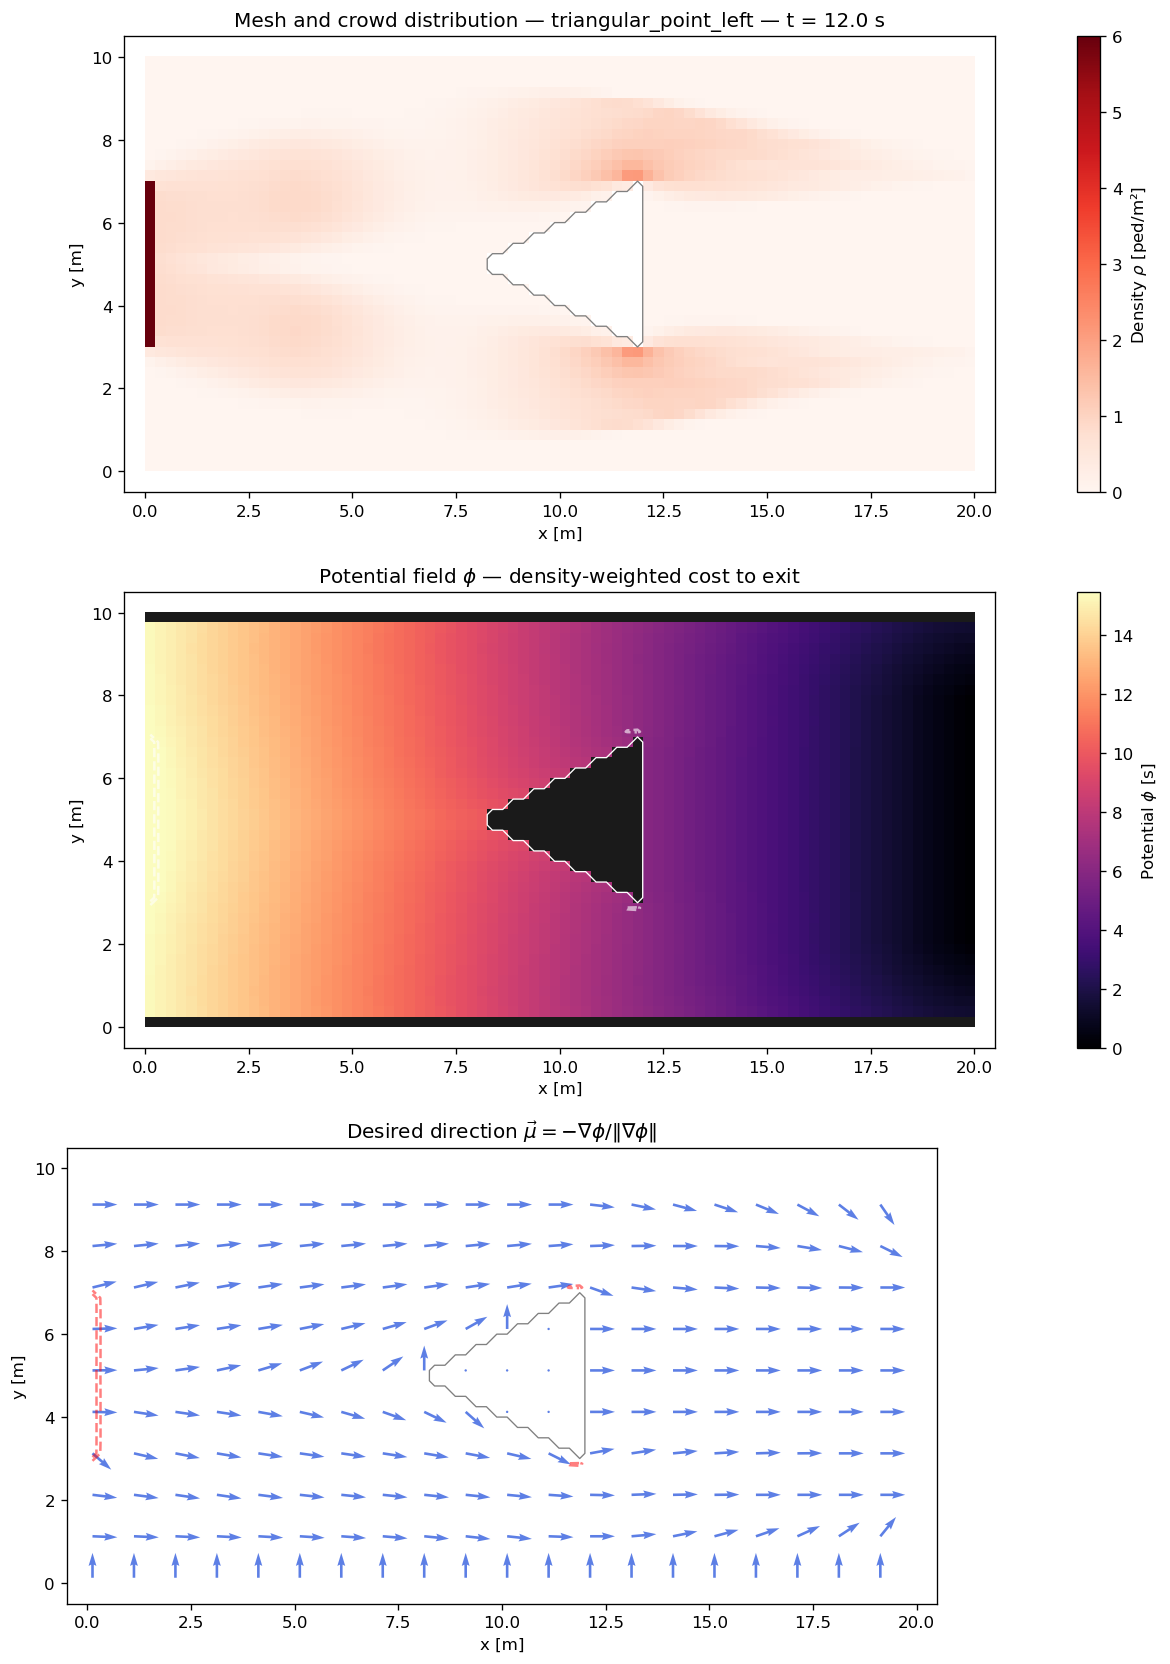

Mesh generated: Nx=80, Ny=40, hx=0.2500, hy=0.2500


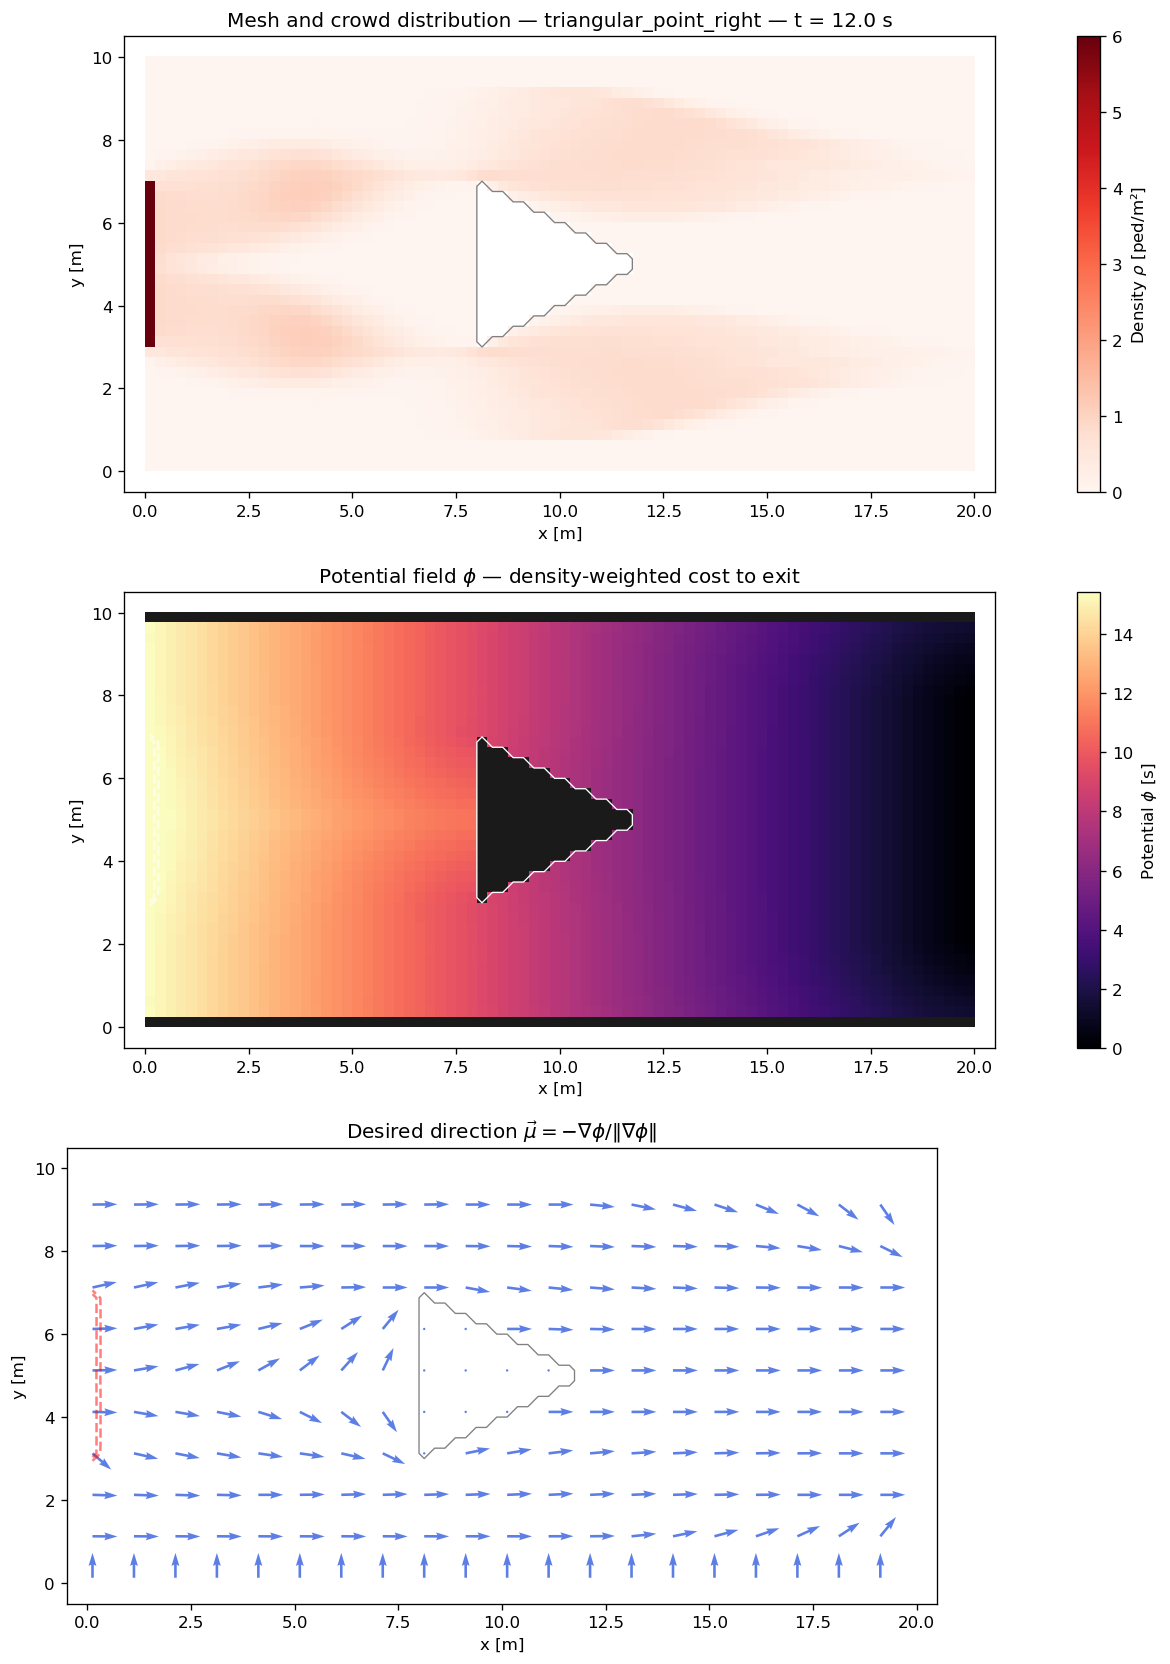

Mesh generated: Nx=80, Ny=40, hx=0.2500, hy=0.2500


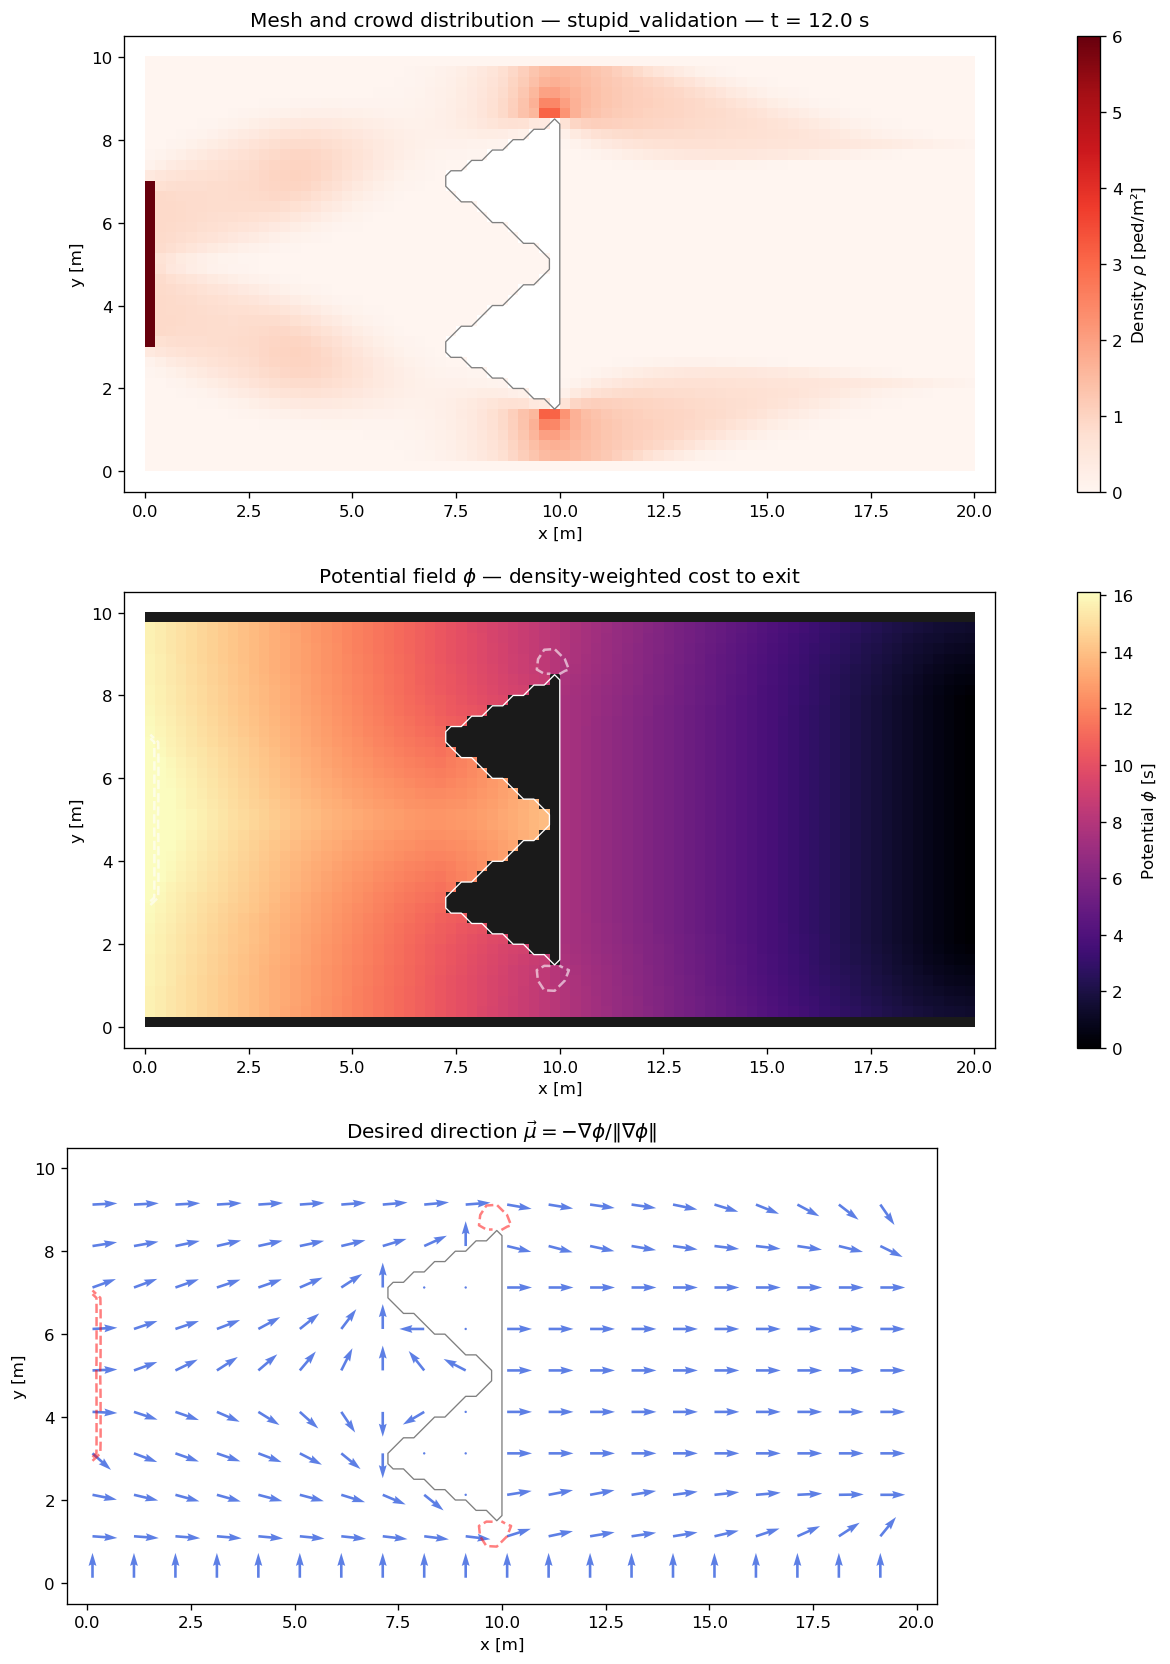

In [27]:
import os
from IPython.display import Image, display

ROOM_CMAP  = plt.get_cmap('Reds').copy();  ROOM_CMAP.set_bad('white')
SNAP_TIMES = [0.0, 3.0, 6.0, 9.0, 12.0, 15.0, 22.5, 30.0]  # matches PW plot_times


def plot_snapshot_3panel(t_target, frames, obs, name, outdir=ROOM_OUT, show=True):
    """Density + potential + direction-field at the snapshot nearest t_target.
    Matches the Payne notebook plot_results layout exactly.
    Unreachable cells (obstacle + walled-off regions) are masked dark in phi."""
    t, rho = min(frames, key=lambda f: abs(f[0] - t_target))

    x_loc, y_loc, X, Y, h = define_mesh(NX_R, NY_R, Lx=LX_R, Ly=LY_R)
    gamma_i, gamma_d, gamma_h = build_room_boundaries(NX_R, NY_R, obs, x_loc, y_loc)
    u   = compute_speed_pw(rho)
    c   = 1.0 / np.maximum(u, 1e-4);  c[obs] = 1e6
    phi = solve_phi_fast_sweeping_first_order(c, gamma_d, gamma_h, NX_R, NY_R, h)
    gx, gy = compute_godunov_gradient(phi, h)
    norm = np.sqrt(gx**2 + gy**2 + 1e-16)
    mx, my = -gx / norm, -gy / norm
    mx[obs] = 0.;  my[obs] = 0.

    # mask obstacle + unreachable walled-off cells (sentinel value 1e6 cost -> phi ~ 1e12)
    SENTINEL  = 1e10
    reachable = (phi < SENTINEL) & (~obs)
    phi_plot  = phi.copy().astype(float);  phi_plot[~reachable] = np.nan
    phi_vmax  = float(np.nanpercentile(phi_plot, 99)) if reachable.any() else 30.0

    Nx, Ny = obs.shape
    xc = (np.arange(Nx) + 0.5) * LX_R / Nx
    yc = (np.arange(Ny) + 0.5) * LY_R / Ny

    fig, axs = plt.subplots(3, 1, figsize=(14, 14))

    # — panel 1: density ———————————————————————————————————————————————————————
    d = rho.copy().astype(float);  d[obs] = np.nan
    im0 = axs[0].imshow(d.T, extent=[0, LX_R, 0, LY_R], origin='lower',
                         cmap=ROOM_CMAP, vmin=0, vmax=RHO_MAX_R, aspect='equal')
    if obs.any():
        axs[0].contour(xc, yc, obs.T.astype(float), levels=[0.5],
                       colors='0.5', linewidths=0.8)
    fig.colorbar(im0, ax=axs[0], label=r'Density $\rho$ [ped/m²]')
    axs[0].set_title(f'Mesh and crowd distribution — {name} — t = {t:.1f} s')

    # — panel 2: potential (unreachable masked dark) ————————————————————————————
    cmap_phi = plt.get_cmap('magma').copy();  cmap_phi.set_bad('#1a1a1a')
    im1 = axs[1].imshow(phi_plot.T, extent=[0, LX_R, 0, LY_R], origin='lower',
                         cmap=cmap_phi, vmin=0, vmax=phi_vmax, aspect='equal')
    if obs.any():
        axs[1].contour(xc, yc, obs.T.astype(float), levels=[0.5],
                       colors='white', linewidths=0.8)
    fig.colorbar(im1, ax=axs[1], label=r'Potential $\phi$ [s]')
    d2 = rho.copy().astype(float);  d2[~reachable] = np.nan
    try:
        axs[1].contour(xc, yc, d2.T, levels=[2.0, 4.0],
                       colors='white', alpha=0.6, linestyles='dashed')
    except Exception:
        pass
    axs[1].set_title(r'Potential field $\phi$ — density-weighted cost to exit')

    # — panel 3: direction field ————————————————————————————————————————————————
    step = max(1, NX_R // 20)
    axs[2].quiver(X[::step, ::step], Y[::step, ::step],
                  mx[::step, ::step], my[::step, ::step],
                  color='royalblue', scale=35, width=0.003, alpha=0.85)
    d3 = rho.copy().astype(float);  d3[obs] = np.nan
    try:
        axs[2].contour(xc, yc, d3.T, levels=[2.0, 4.0],
                       colors='red', alpha=0.5, linestyles='dashed')
    except Exception:
        pass
    if obs.any():
        axs[2].contour(xc, yc, obs.T.astype(float), levels=[0.5],
                       colors='0.5', linewidths=0.8)
    axs[2].set_title(r'Desired direction $\vec{\mu} = -\nabla\phi / \|\nabla\phi\|$')

    for ax in axs:
        ax.set_aspect('equal')
        ax.set_xlabel('x [m]');  ax.set_ylabel('y [m]')
        ax.set_xlim(-0.5, LX_R + 0.5);  ax.set_ylim(-0.5, LY_R + 0.5)

    plt.tight_layout()
    os.makedirs(outdir, exist_ok=True)
    p = os.path.join(outdir, f'3panel_{name}_t{int(round(t_target)):02d}.png')
    fig.savefig(p, dpi=120, bbox_inches='tight');  plt.close(fig)
    if show:
        display(Image(filename=p))
    return p


# run at peak-wave time (t=12 s) for all 6 geometries
for name, res in room_results.items():
    plot_snapshot_3panel(12.0, res['frames'], res['obs'], name)


### 3.6 Graph 2 — Mass conservation (4-panel, per geometry)

Mirrors the Payne notebook's `PedestrianCounter.plot_conservation`:

- **Panel 1** – mass in domain m(t) vs the expected balance (entered − exited).
- **Panel 2** – cumulative inflow and outflow; blue shading marks the three
  active inflow waves.
- **Panel 3** – congestion integral: Σ max(ρ−ρ_safe, 0)² · cell_area over
  walkable cells (instantaneous; not yet time-integrated). C_cong is the
  trapezoid integral normalised by total people entered.
- **Panel 4** – balance error m(t) − (entered − exited). Hughes has no limiter
  term (no momentum clipping), so this is purely numerical error; it should
  stay near machine precision.

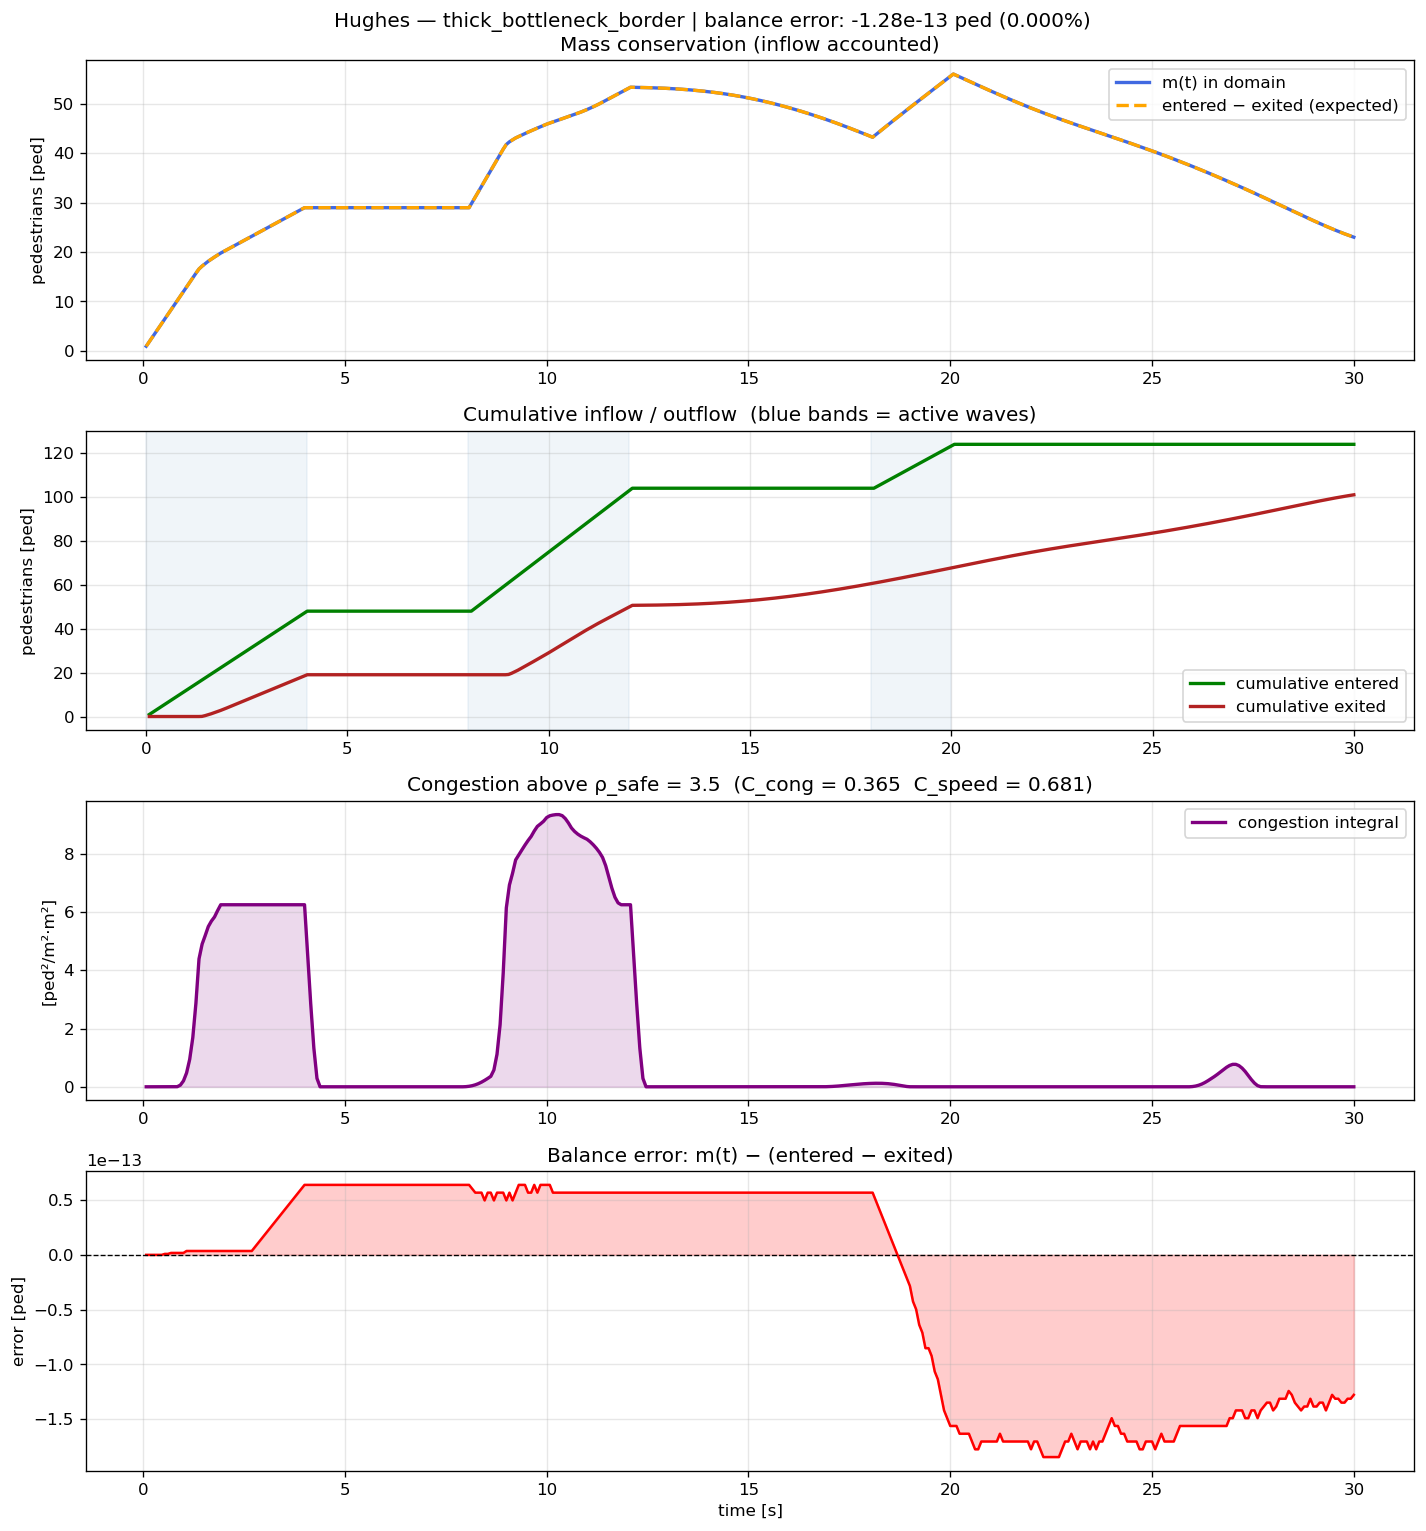

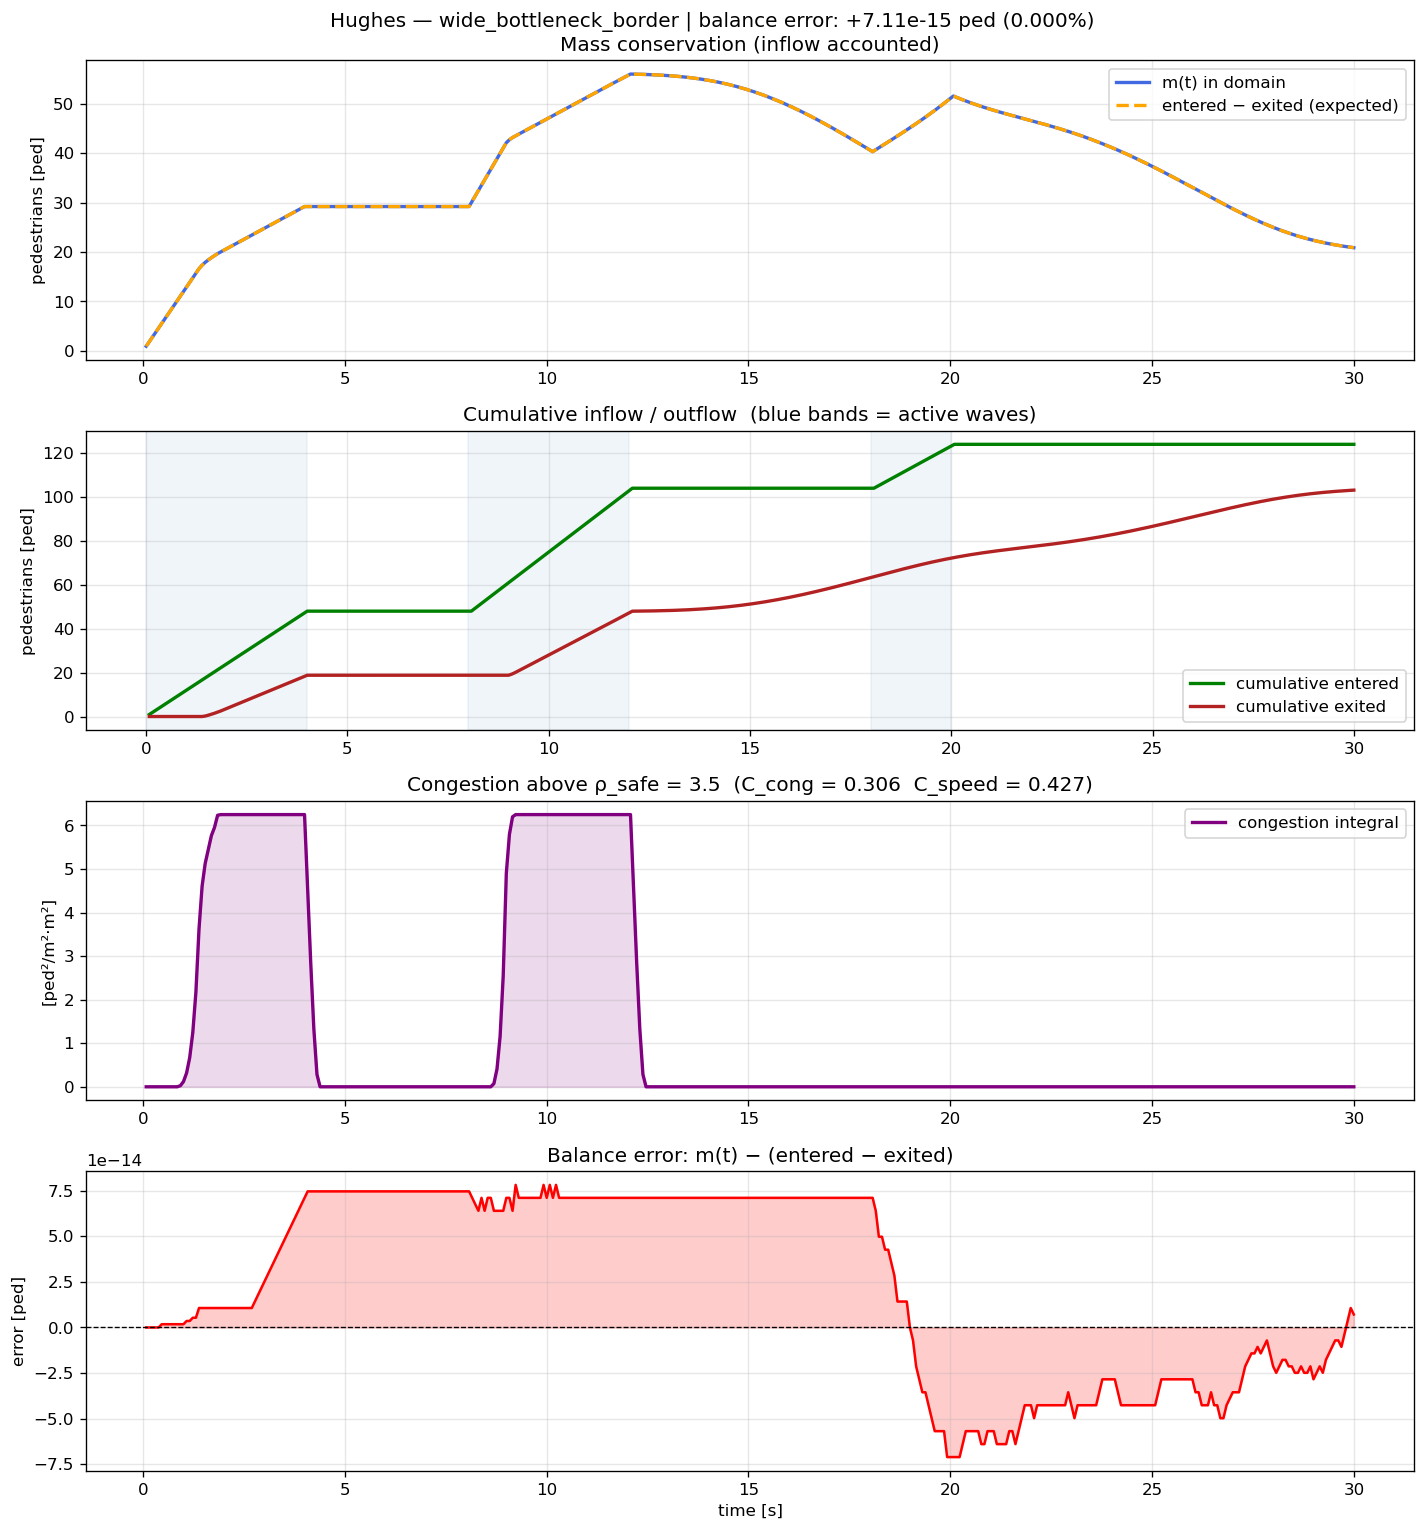

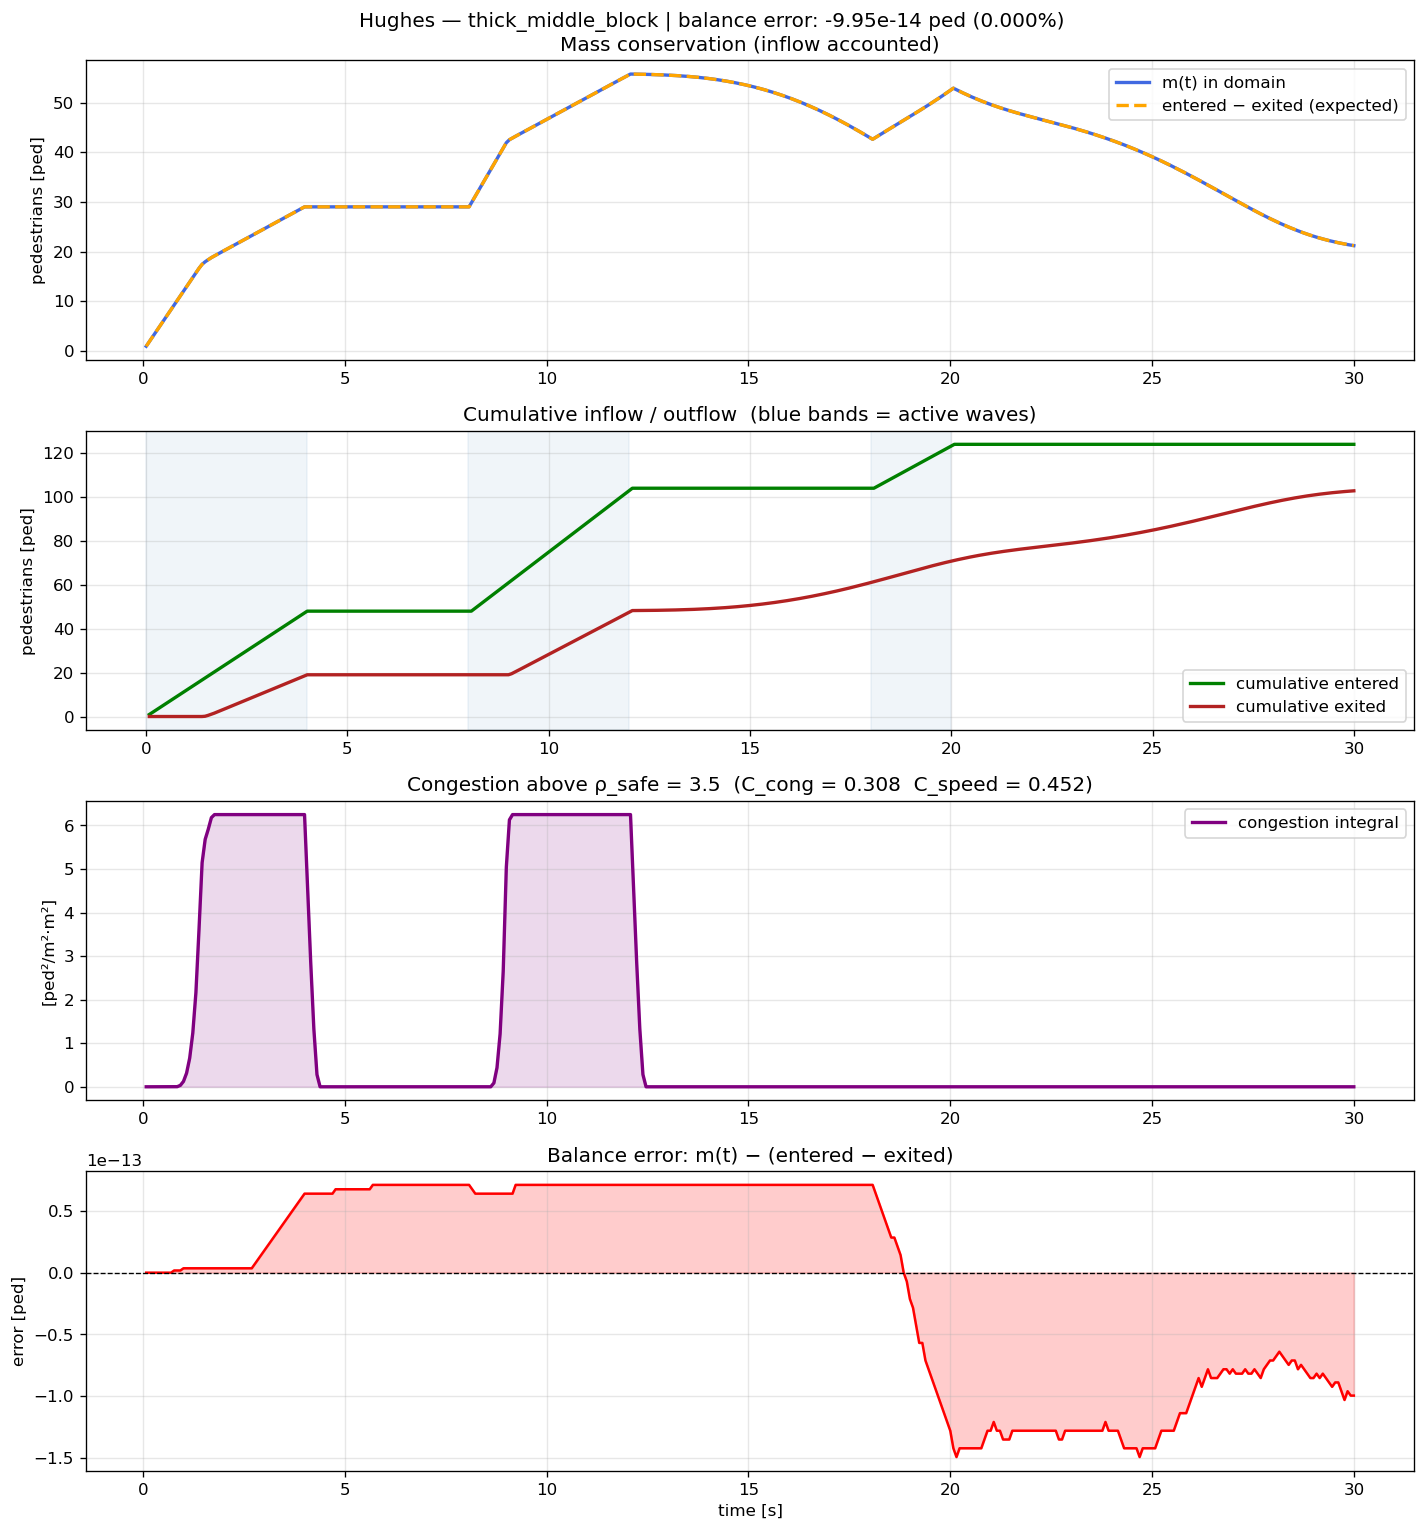

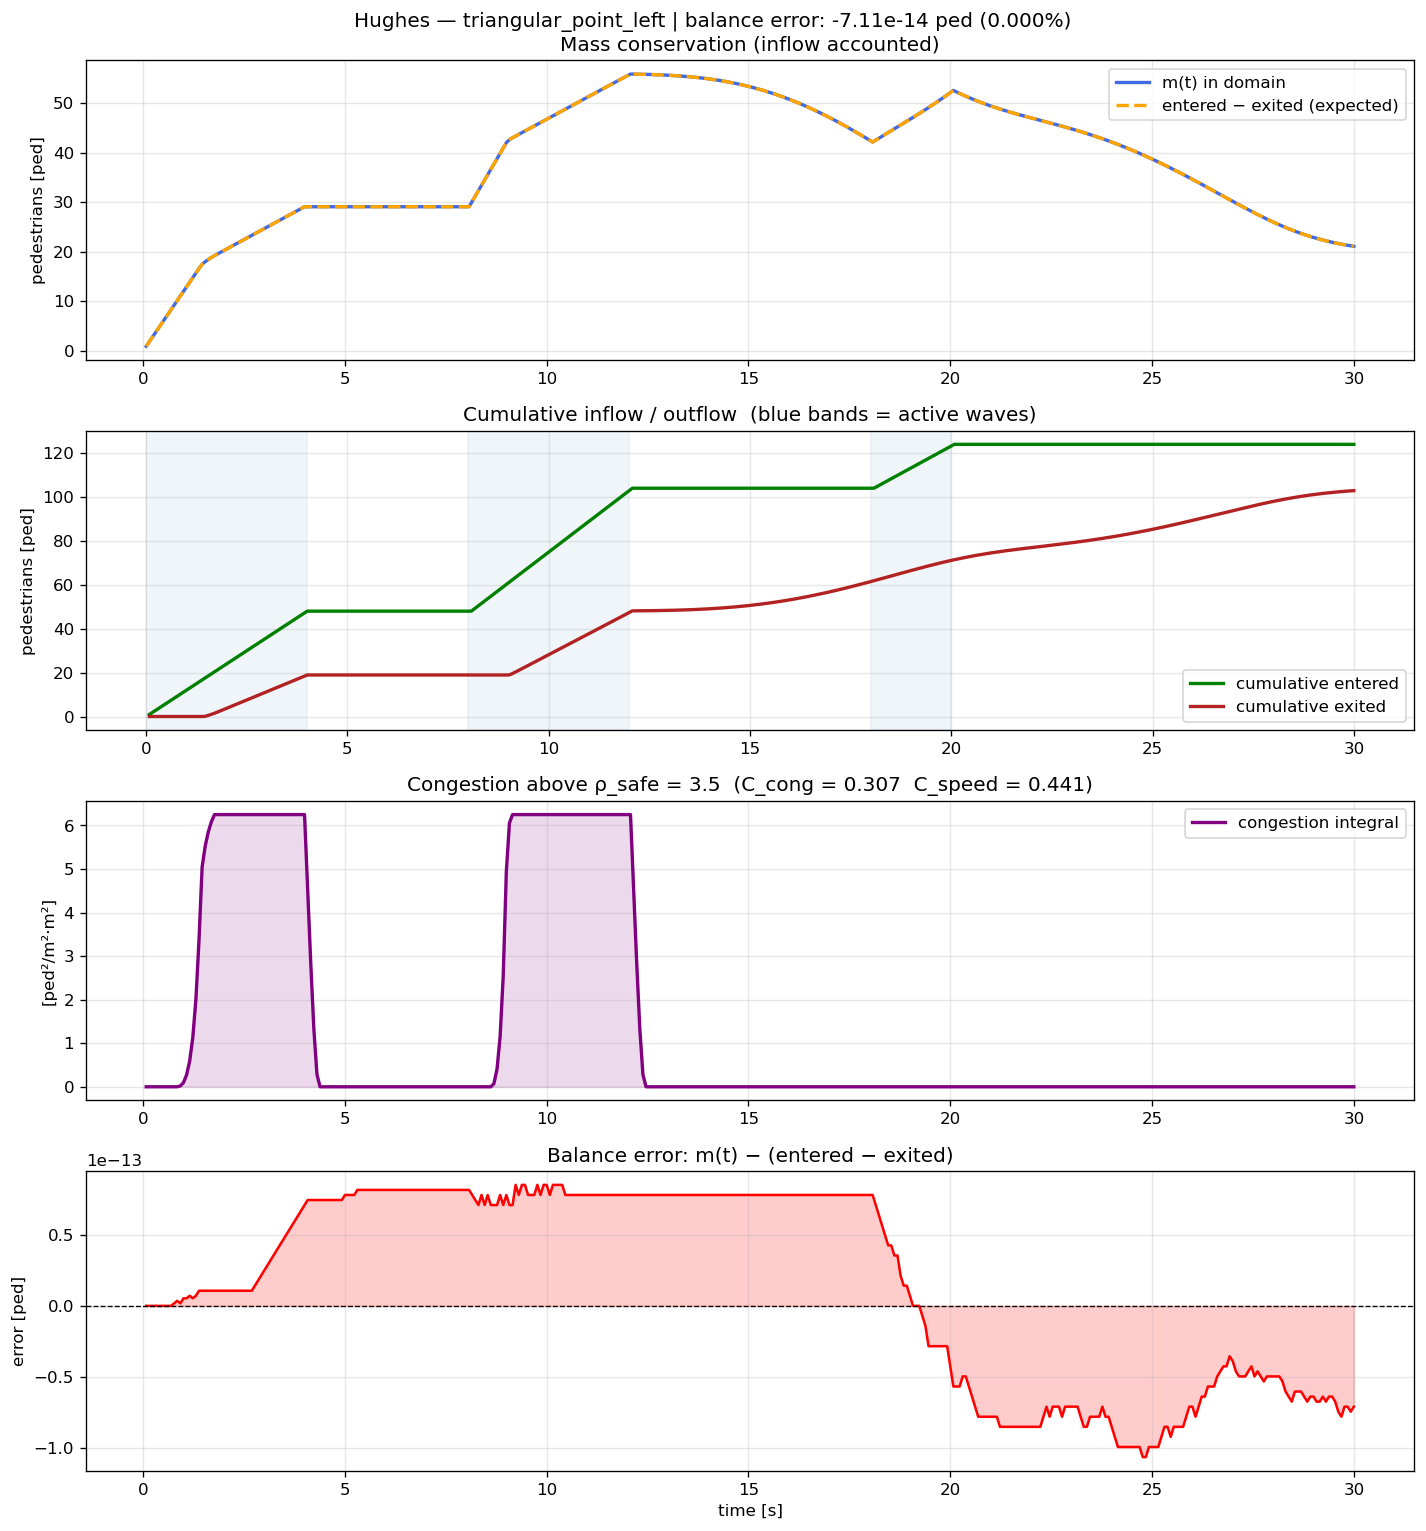

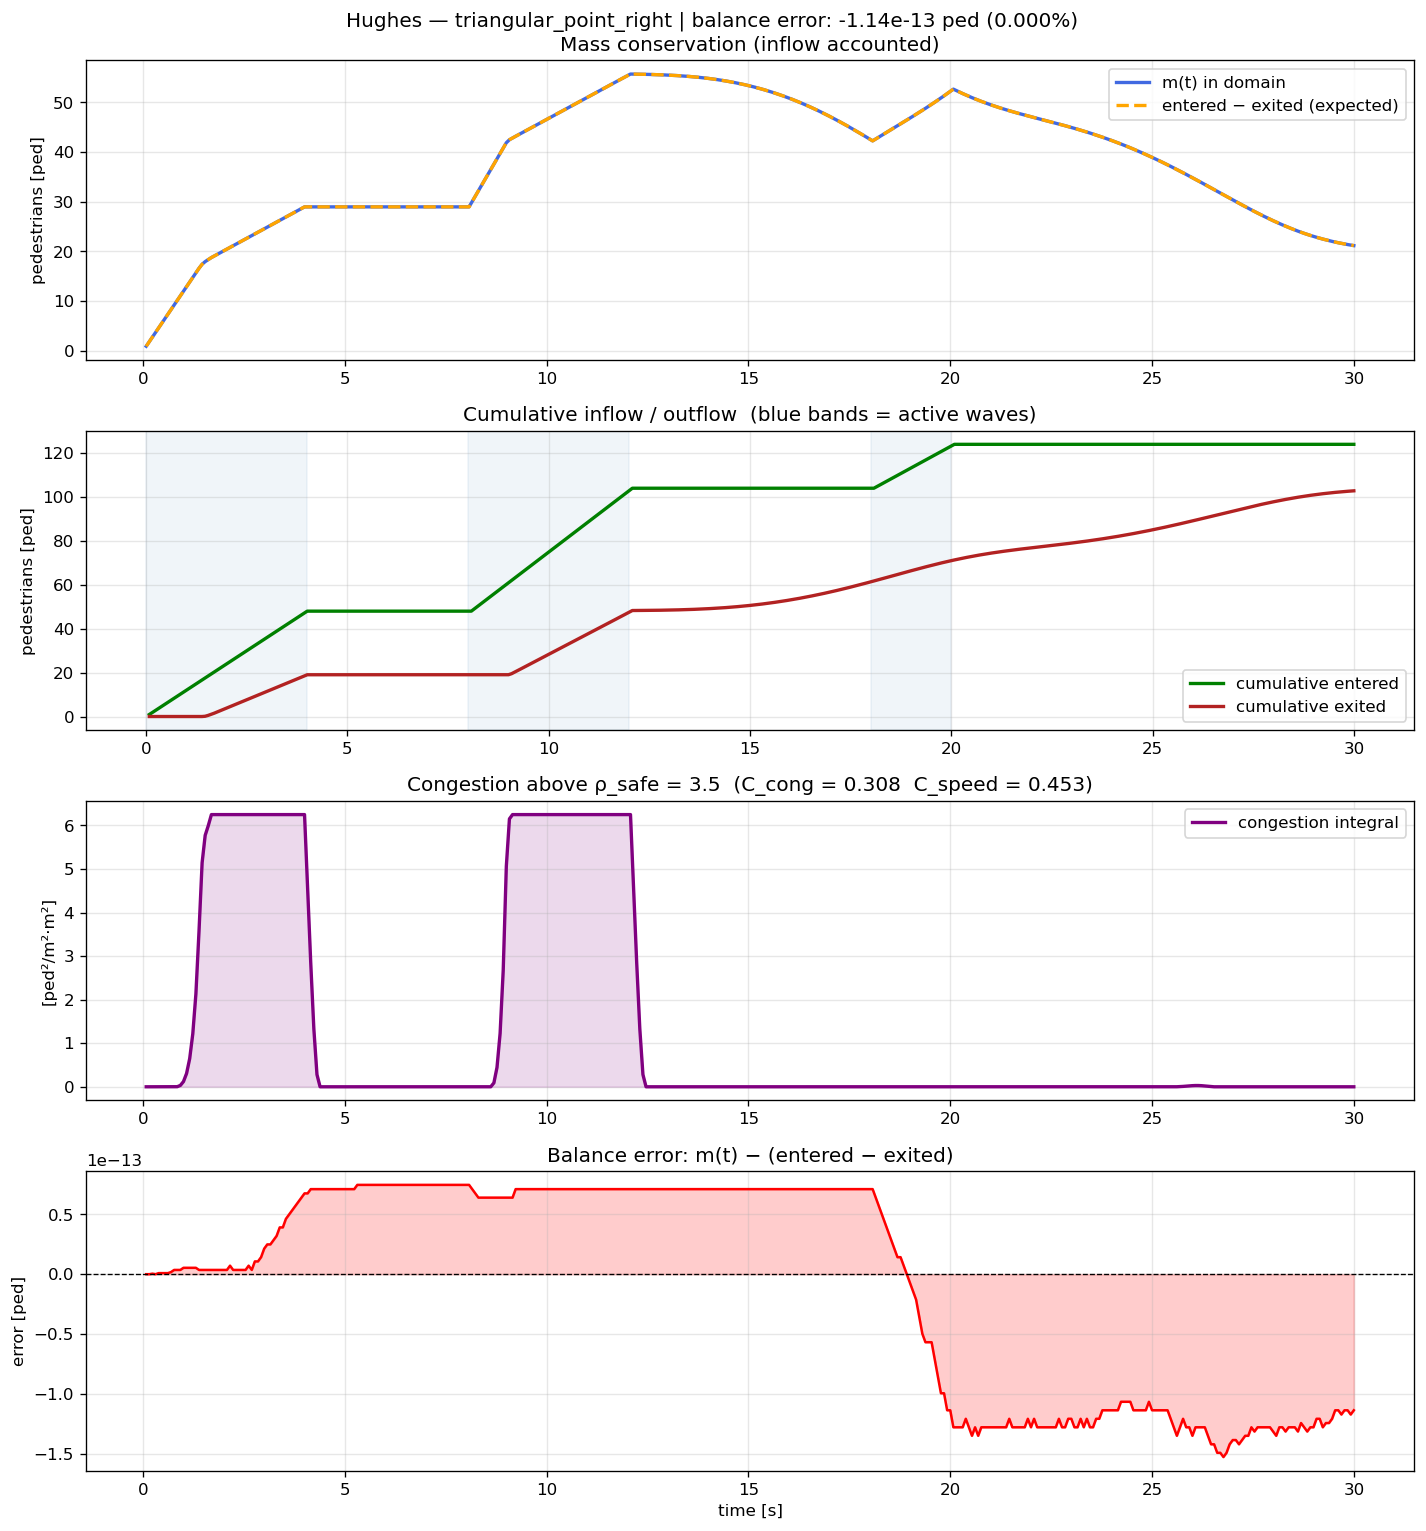

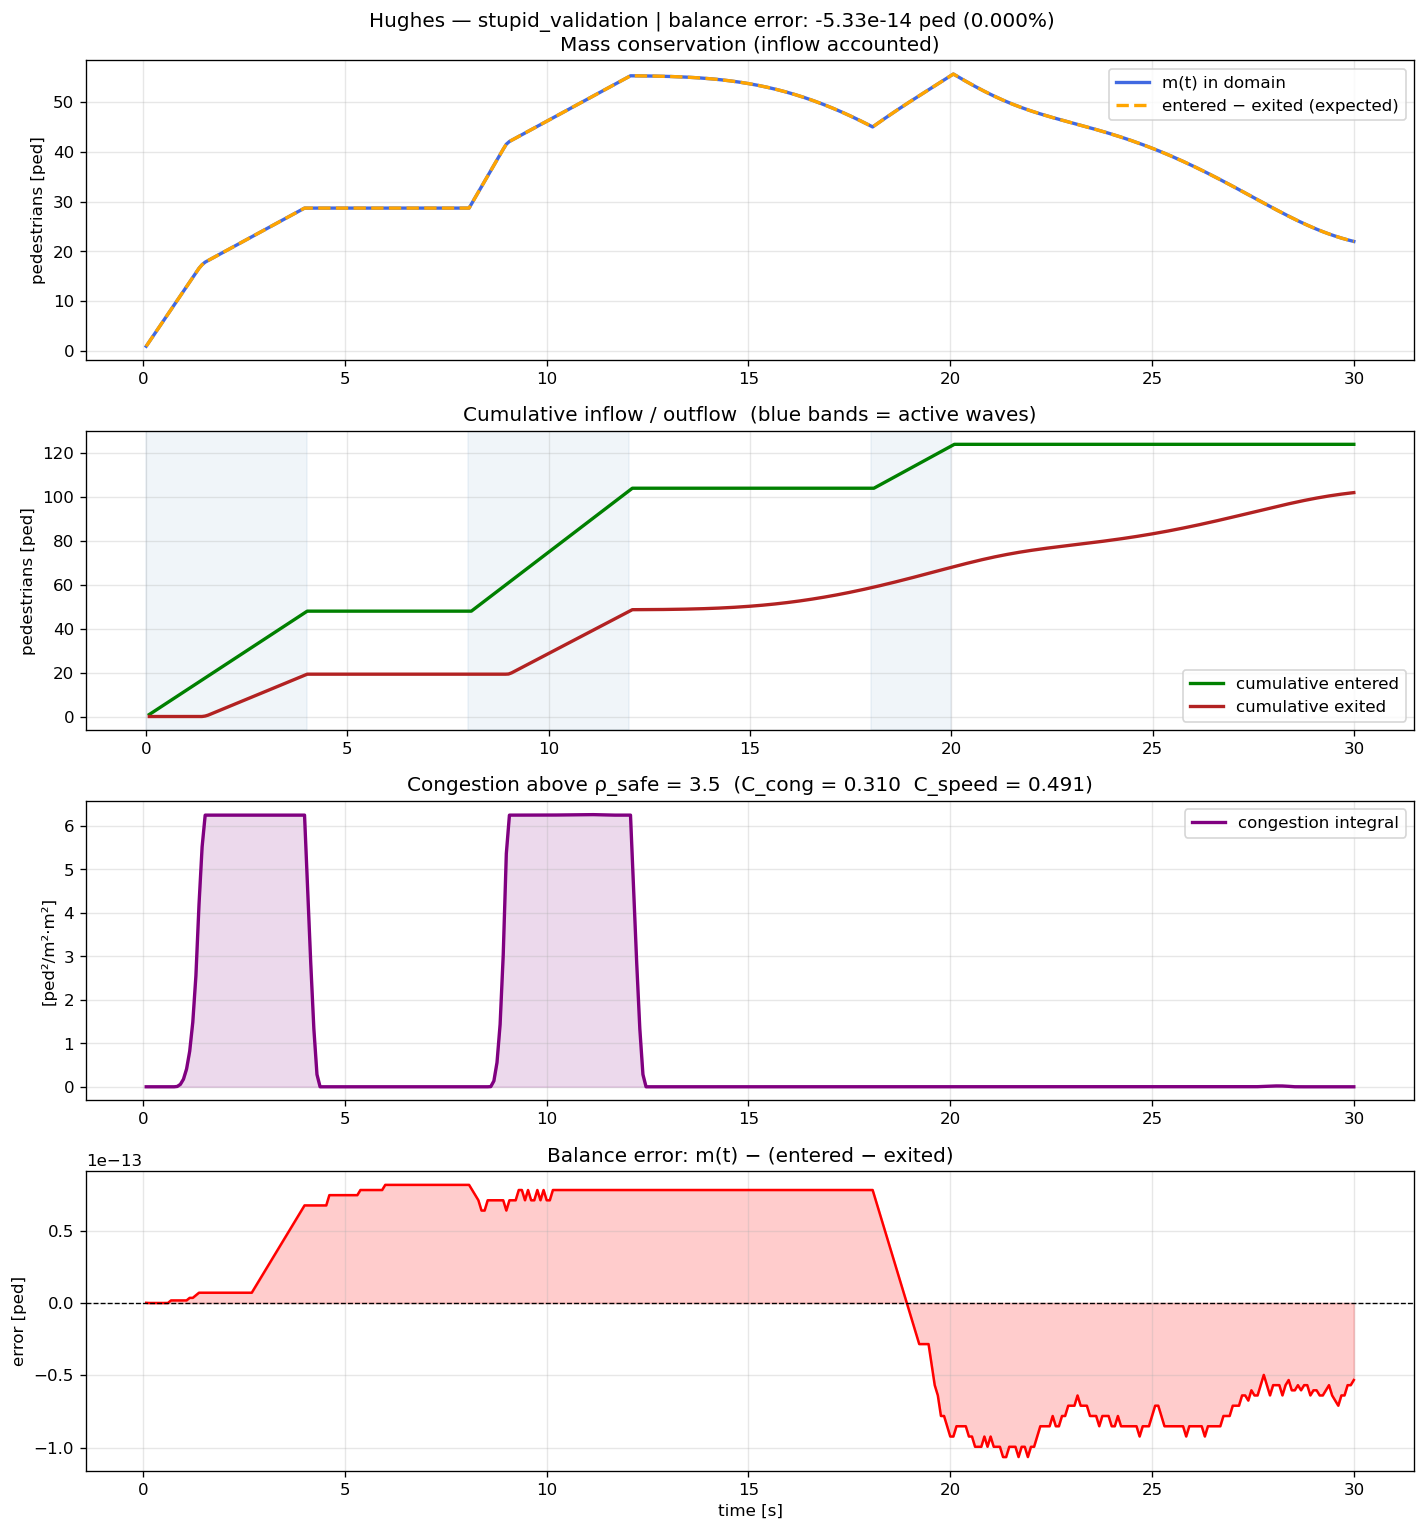

In [28]:
def plot_conservation(res, name, outdir=ROOM_OUT, show=True):
    """4-panel mass-conservation figure, matching PedestrianCounter.plot_conservation."""
    ts   = res['ts'];  M_d = res['M_d']
    M_ci = res['M_ci'];  M_co = res['M_co']
    balance = M_d - (M_ci - M_co)

    fig, axs = plt.subplots(4, 1, figsize=(12, 13))

    # — panel 1: mass in domain ——————————————————————————————————————————————
    axs[0].plot(ts, M_d,       color='royalblue', lw=2, label='m(t) in domain')
    axs[0].plot(ts, M_ci - M_co, color='orange', lw=2, ls='--',
                label='entered − exited (expected)')
    axs[0].set_ylabel('pedestrians [ped]')
    axs[0].set_title('Mass conservation (inflow accounted)')
    axs[0].legend();  axs[0].grid(True, alpha=0.3)

    # — panel 2: cumulative in/out + wave shading ————————————————————————————
    axs[1].plot(ts, M_ci, color='green',     lw=2, label='cumulative entered')
    axs[1].plot(ts, M_co, color='firebrick', lw=2, label='cumulative exited')
    for t0, t1, _, _ in ROOM_WAVES:
        axs[1].axvspan(t0, t1, alpha=0.08, color='steelblue')
    axs[1].set_ylabel('pedestrians [ped]')
    axs[1].set_title('Cumulative inflow / outflow  (blue bands = active waves)')
    axs[1].legend();  axs[1].grid(True, alpha=0.3)

    # — panel 3: instantaneous congestion integral ———————————————————————————
    axs[2].plot(ts, res['rho_safe_series'], color='purple', lw=2,
                label='congestion integral')
    axs[2].fill_between(ts, res['rho_safe_series'], 0, alpha=0.15, color='purple')
    axs[2].set_ylabel(r'[ped²/m²·m²]')
    axs[2].set_title(
        f'Congestion above ρ_safe = 3.5  '
        f'(C_cong = {res["C_cong"]:.3f}  '
        f'C_speed = {res["C_speed"]:.3f})')
    axs[2].legend();  axs[2].grid(True, alpha=0.3)

    # — panel 4: balance error ————————————————————————————————————————————————
    axs[3].plot(ts, balance, color='red', lw=1.5)
    axs[3].axhline(0, color='black', lw=0.8, ls='--')
    axs[3].fill_between(ts, balance, 0, alpha=0.2, color='red')
    axs[3].set_ylabel('error [ped]');  axs[3].set_xlabel('time [s]')
    axs[3].set_title('Balance error: m(t) − (entered − exited)')
    axs[3].grid(True, alpha=0.3)

    ref    = max(M_ci[-1], 1.0)
    pct    = abs(balance[-1]) / ref * 100
    fig.suptitle(
        f'Hughes — {name} | balance error: {balance[-1]:+.2e} ped ({pct:.3f}%)',
        fontsize=12)
    plt.tight_layout()
    os.makedirs(outdir, exist_ok=True)
    p = os.path.join(outdir, f'conservation_{name}.png')
    fig.savefig(p, dpi=120, bbox_inches='tight');  plt.close(fig)
    if show:
        display(Image(filename=p))
    return p


for name, res in room_results.items():
    plot_conservation(res, name)


### 3.7 Graph 3 — Loss function ranking (all geometries, single figure)

Mirrors the Payne notebook's final ranking table and `crowd_flow_loss`.
Same formula: **loss = T_av + 0.05·C_cong + 0.05·C_speed**.

- **T_av** (s): average time a pedestrian spends inside = ∫m(t)dt / total_entered.
  Smaller = faster evacuation.
- **C_cong**: time-integral of the area-weighted excess density squared above
  ρ_safe = 3.5 ped/m², normalised by total people. Smaller = less jam.
- **C_speed**: time-integral of density-weighted speed-loss (v_max − v_eq)²,
  normalised by total people. Smaller = people moving closer to free speed.

Ranking (#1 = best) is annotated on the total-loss line.

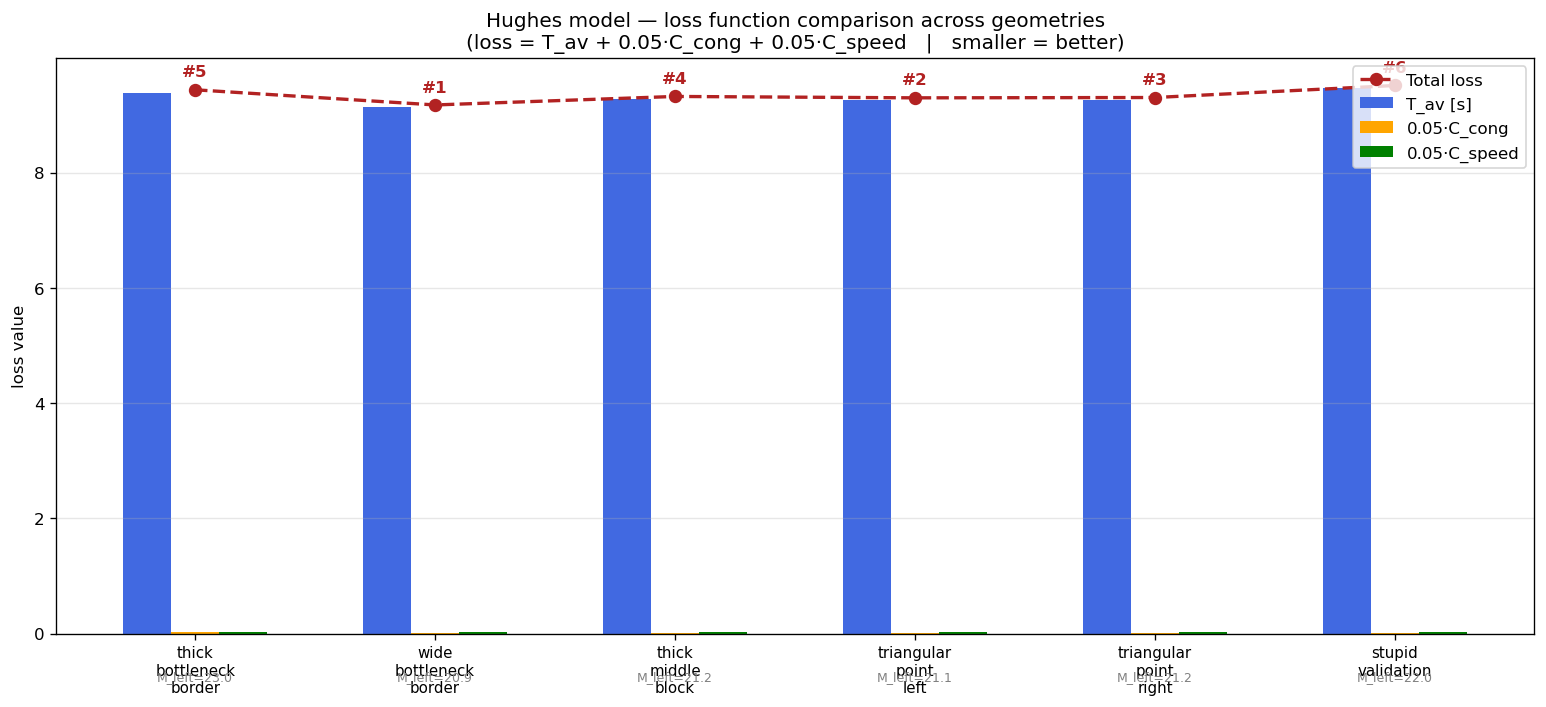


Rank Geometry                       loss    T_av   C_cong   C_speed  M_left
---------------------------------------------------------------------------
#1   wide_bottleneck_border        9.173    9.14    0.306     0.427    20.9
#2   triangular_point_left         9.297    9.26    0.307     0.441    21.1
#3   triangular_point_right        9.302    9.26    0.308     0.453    21.2
#4   thick_middle_block            9.321    9.28    0.308     0.452    21.2
#5   thick_bottleneck_border       9.436    9.38    0.365     0.681    23.0
#6   stupid_validation             9.511    9.47    0.310     0.491    22.0


'C:\\Users\\giuli\\Downloads\\hughes_payne_comparison\\loss_ranking.png'

In [29]:
def plot_loss_ranking(room_results, outdir=ROOM_OUT, show=True):
    """Grouped bar chart of loss terms + total loss line, with ranking labels."""
    names  = list(room_results.keys())
    T_avs  = [room_results[n]['T_av']             for n in names]
    C_cs   = [room_results[n]['C_cong'] * 0.05    for n in names]
    C_ss   = [room_results[n]['C_speed'] * 0.05   for n in names]
    losses = [room_results[n]['loss']              for n in names]
    M_left = [room_results[n]['M_left']            for n in names]
    short  = [n.replace('_', '\n') for n in names]

    x = np.arange(len(names));  w = 0.2
    fig, ax = plt.subplots(figsize=(13, 6))

    ax.bar(x - w,   T_avs, w, label='T_av [s]',        color='royalblue')
    ax.bar(x,       C_cs,  w, label='0.05·C_cong',      color='orange')
    ax.bar(x + w,   C_ss,  w, label='0.05·C_speed',     color='green')
    ax.plot(x, losses, 'o--', color='firebrick', lw=2, ms=7, label='Total loss')

    # rank annotations
    ranked = sorted(enumerate(losses), key=lambda v: v[1])
    for rank, (i, l) in enumerate(ranked):
        ax.annotate(f'#{rank+1}', xy=(x[i], l),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=10, color='firebrick', fontweight='bold')

    ax.set_xticks(x);  ax.set_xticklabels(short, rotation=0, ha='center', fontsize=9)
    ax.set_ylabel('loss value')
    ax.set_title(
        'Hughes model — loss function comparison across geometries\n'
        '(loss = T_av + 0.05·C_cong + 0.05·C_speed   |   smaller = better)')
    ax.legend(loc='upper right');  ax.grid(True, alpha=0.3, axis='y')

    # secondary table below bars
    for i, n in enumerate(names):
        ax.annotate(
            f'M_left={M_left[i]:.1f}',
            xy=(x[i], 0), xytext=(0, -28), textcoords='offset points',
            ha='center', fontsize=7.5, color='gray')

    plt.tight_layout()
    os.makedirs(outdir, exist_ok=True)
    p = os.path.join(outdir, 'loss_ranking.png')
    fig.savefig(p, dpi=120, bbox_inches='tight');  plt.close(fig)
    if show:
        display(Image(filename=p))

    # print ranking table
    print(f"\n{'Rank':<5}{'Geometry':<28}{'loss':>7}{'T_av':>8}{'C_cong':>9}{'C_speed':>10}{'M_left':>8}")
    print('-' * 75)
    for rank, (i, l) in enumerate(ranked):
        n = names[i]
        r = room_results[n]
        print(f"#{rank+1:<4}{n:<28}{l:>7.3f}{r['T_av']:>8.2f}"
              f"{r['C_cong']:>9.3f}{r['C_speed']:>10.3f}{r['M_left']:>8.1f}")

    return p


plot_loss_ranking(room_results)
